# PTT 房屋版中房價、買房與政策討論之社群媒體分析

本 Notebook 以 PTT 房屋版 home-sale 作為單一資料來源，蒐集文章與推文，進行中文斷詞、高頻詞、TF-IDF、情緒分析、推文類型分析與關鍵詞共現網路分析。

資料來源：PTT 房屋版 home-sale  
網址：https://www.ptt.cc/bbs/home-sale/index.html

> 使用提醒：本 Notebook 設計給 Google Colab 從上到下直接執行。若 PTT 暫時無法連線或爬蟲失敗，可改用後面提供的「手動上傳 CSV」替代方案，再繼續後續分析。

小組成員:
N134020003_楊凱傑
N134020006_陳信宏
N134320016_盧柔樺


## A. *動機和分析目的

PTT 房屋版是台灣網路社群中長期討論房價、買房、租屋、貸款與房市政策的重要場域。相較於新聞或官方統計，PTT 討論更接近一般民眾、首購族、投資者、房東房客與房仲相關從業者的即時觀點，因此適合作為社群媒體分析資料。

房價、買房、租屋與政策議題具有社會與產業分析價值，原因包括：

1. 房價與租金直接影響居住負擔與家庭財務規劃。
2. 房貸利率、限貸、稅制與補貼政策會改變購屋決策與市場預期。
3. 社群討論能反映民眾對房市景氣、政策公平性與未來價格走勢的感受。
4. 房市議題涉及建商、仲介、銀行、政府政策與一般消費者，具有跨產業分析意義。

本專案希望回答以下問題：

1. PTT 房屋版最常討論哪些房市議題？
2. 網友對房價與買房的情緒偏正面、負面或中立？
3. 哪些關鍵字最能代表房屋版討論焦點？
4. 房市政策是否是熱門討論主題？

## 一、安裝與匯入套件

第一個程式區塊會安裝本專案需要的套件。Google Colab 每次重新啟動環境後都需要重新安裝。

In [14]:
!pip install requests beautifulsoup4 lxml pandas numpy jieba scikit-learn matplotlib wordcloud networkx snownlp
!pip install transformers torch

### 中文字型設定

Colab 預設字型有時無法正常顯示中文。下面會嘗試安裝 Noto Sans CJK 字型，並設定 matplotlib 使用中文字型。

In [16]:
# 安裝中文字型，避免圖表中文字變成方塊
!apt-get -qq update
!apt-get -qq install -y fonts-noto-cjk

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_candidates = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc',
]
font_path = next((p for p in font_candidates if __import__('os').path.exists(p)), None)

if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'

plt.rcParams['axes.unicode_minus'] = False
print('中文字型設定完成:', font_path)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
中文字型設定完成: /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


## 二、建立 Colab 資料夾

本專案會把原始資料、清理後資料、圖表與報告文字分別存放在不同資料夾。

In [17]:
import os

folders = ['data_raw', 'data_processed', 'figures', 'report']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print('資料夾建立完成:', folders)

資料夾建立完成: ['data_raw', 'data_processed', 'figures', 'report']


## 三、PTT 房屋版爬蟲
改成以Tarflow完成爬蟲作業，放上Goole Drive，讓Colab直接從連結載入。
時間：1140601-1150531

In [18]:
import gdown
import os

# 確保資料夾存在
os.makedirs('data_raw', exist_ok=True)

# Google Drive file ID from the provided link
file_id = '1IvQEURwfXK5y8jJCL6D8qOKpKIMAGPQ-'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'data_raw/ptt_home_sale_articles.csv'

# Download the file
gdown.download(url, output, quiet=False)

print(f'檔案已下載並儲存至: {output}')

Downloading...
From: https://drive.google.com/uc?id=1IvQEURwfXK5y8jJCL6D8qOKpKIMAGPQ-
To: /content/data_raw/ptt_home_sale_articles.csv
100%|██████████| 105M/105M [00:00<00:00, 133MB/s]

檔案已下載並儲存至: data_raw/ptt_home_sale_articles.csv


In [19]:
import pandas as pd

# 重新讀取下載後的資料以確保後續分析正常執行
articles_df = pd.read_csv('data_raw/ptt_home_sale_articles.csv')
print('成功載入文章資料，筆數:', len(articles_df))
display(articles_df.head())

成功載入文章資料，筆數: 9835


,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/home-sale/M.1748709086.A.FC6.html,Re:[閒聊]科技進步對房價（探索裕隆城,2025-06-01 00:31:24,sdbb,home_sale,"先說，敬祝各位端午佳節愉快\n長文，以前 BBS 連線板叫""金魚大便流""，又臭又長\n對，所謂公平，不是人人都一樣\n\n""我有你沒有的，你有我沒有的，也是公平""\nStar Trek：試試無線點對點傳輸\n[恕刪]\n買新莊，搭火...","[{""cmtStatus"": ""推"", ""cmtPoster"": ""ceca"", ""cmtContent"": "":這篇不要讓阿龍看到.求求"", ""cmtDate"": ""2025-06-01 00:46:00""}, {""cmtStat...",112.104.65.143,2025-06-01 01:24:16,ptt
1,2,https://www.ptt.cc/bbs/home-sale/M.1748712781.A.F21.html,Re:[請益]政府如打房會沒選票是怎麼得出來的?,2025-06-01 01:32:59,spermbox,home_sale,這個問題，你反向思考就會懂\n\n假設打房會得民心，得民心就可以勝選和連任：\n\n那台灣從地方首長開始民選制度以來\n怎麼從來都沒有一路上從競選-執政-選連任-第二任，都堅定走打房路線的政治人物？\n\n台灣民選政治的歷史可不是短...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""buike"", ""cmtContent"": "":打不打房其次，喊一喊抗中保台就當選超簡單"", ""cmtDate"": ""2025-06-01 01:59:00""}, ...",39.9.167.146,2025-06-02 01:21:57,ptt
2,3,https://www.ptt.cc/bbs/home-sale/M.1748727003.A.401.html,[新聞]預售前10熱區桃園包辦6區「兩區」房價,2025-06-01 05:30:01,yokann,home_sale,預售前10熱區 桃園包辦6區 「兩區」房價倒數3字頭\n\n連結：\nhttps://estate.ltn.com.tw/article/24365\n內文：房仲業者統計今年Q1全台預售前銷售10大熱區，在交易量前10名榜單中，桃園...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""backpacker18"", ""cmtContent"": "":桃園真便宜"", ""cmtDate"": ""2025-06-01 06:07:00""}, {""cmtSta...",1.171.34.75,2025-06-02 01:21:57,ptt
3,4,https://www.ptt.cc/bbs/home-sale/M.1748735945.A.C17.html,[情報]好房網5月份房價,2025-06-01 07:59:02,jemdogdog,home_sale,好房網 重點縣市成交漲跌排行\nhttps://price.housefun.com.tw/%E8%A1%8C%E6%83%85%E8%B3%87%E8%A8%8A/\n點選 ->區域實價登錄趨勢\n\n2025年\n\n5月\n\...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""lucky466"", ""cmtContent"": "":台南漲的時候狗兄就貼的很快速，讚"", ""cmtDate"": ""2025-06-01 08:03:00""}, {...",27.242.34.205,2025-06-02 01:21:57,ptt
4,5,https://www.ptt.cc/bbs/home-sale/M.1748741944.A.E03.html,[賣/新竹/香山]降價百達翡麗主附27坪採光大三房,2025-06-01 09:39:01,dindon0320,home_sale,本人同意並願意遵守現行法律、本站使用者條款、本站各級規定、本板所有規範，\n本人願意為本文內容負責，並保証本文內容皆詳盡屬實，若違反相關規範，願受處分。\n本文僅授權發表於PTT實業坊，未經同意不得轉載至其它網站，否則得視情況提出告...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""gg4wada"", ""cmtContent"": "":1835禮拜一發薪水裝備下斡旋！"", ""cmtDate"": ""2025-06-01 16:15:00""}, {""...",61.222.79.228,2025-06-02 01:21:57,ptt


## B. 資料集的描述

本研究資料來源為 PTT 房屋版 home-sale，爬蟲從首頁開始往前蒐集指定頁數，預設為 10 頁。資料分成兩個表格：文章資料與推文資料。

文章資料欄位包含 board、article_id、article_url、title、author、post_date、content、push_count、boo_count、neutral_count、total_comment_count、crawled_at。推文資料欄位包含 article_id、article_url、comment_type、commenter、comment_text、comment_time。

資料限制包括：PTT 使用者不等於全體台灣民眾，討論可能受到熱門事件與短期新聞影響，且 SnowNLP 的中文情緒分析不一定完全符合台灣房市語境。倫理上，本專案只使用公開資料，並於報告中避免呈現完整使用者 ID。

## 四、資料前處理

本段會讀取原始 CSV，移除網址、特殊符號、PTT 系統文字與過短文章，合併標題與內文後使用 jieba 斷詞。

In [20]:
#from google.colab import drive
#drive.mount('/content/drive')

import pandas as pd

articles_df = pd.read_csv('data_raw/ptt_home_sale_articles.csv')
articles_df.head()

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/home-sale/M.1748709086.A.FC6.html,Re:[閒聊]科技進步對房價（探索裕隆城,2025-06-01 00:31:24,sdbb,home_sale,"先說，敬祝各位端午佳節愉快\n長文，以前 BBS 連線板叫""金魚大便流""，又臭又長\n對，所謂公平，不是人人都一樣\n\n""我有你沒有的，你有我沒有的，也是公平""\nStar Trek：試試無線點對點傳輸\n[恕刪]\n買新莊，搭火...","[{""cmtStatus"": ""推"", ""cmtPoster"": ""ceca"", ""cmtContent"": "":這篇不要讓阿龍看到.求求"", ""cmtDate"": ""2025-06-01 00:46:00""}, {""cmtStat...",112.104.65.143,2025-06-01 01:24:16,ptt
1,2,https://www.ptt.cc/bbs/home-sale/M.1748712781.A.F21.html,Re:[請益]政府如打房會沒選票是怎麼得出來的?,2025-06-01 01:32:59,spermbox,home_sale,這個問題，你反向思考就會懂\n\n假設打房會得民心，得民心就可以勝選和連任：\n\n那台灣從地方首長開始民選制度以來\n怎麼從來都沒有一路上從競選-執政-選連任-第二任，都堅定走打房路線的政治人物？\n\n台灣民選政治的歷史可不是短...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""buike"", ""cmtContent"": "":打不打房其次，喊一喊抗中保台就當選超簡單"", ""cmtDate"": ""2025-06-01 01:59:00""}, ...",39.9.167.146,2025-06-02 01:21:57,ptt
2,3,https://www.ptt.cc/bbs/home-sale/M.1748727003.A.401.html,[新聞]預售前10熱區桃園包辦6區「兩區」房價,2025-06-01 05:30:01,yokann,home_sale,預售前10熱區 桃園包辦6區 「兩區」房價倒數3字頭\n\n連結：\nhttps://estate.ltn.com.tw/article/24365\n內文：房仲業者統計今年Q1全台預售前銷售10大熱區，在交易量前10名榜單中，桃園...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""backpacker18"", ""cmtContent"": "":桃園真便宜"", ""cmtDate"": ""2025-06-01 06:07:00""}, {""cmtSta...",1.171.34.75,2025-06-02 01:21:57,ptt
3,4,https://www.ptt.cc/bbs/home-sale/M.1748735945.A.C17.html,[情報]好房網5月份房價,2025-06-01 07:59:02,jemdogdog,home_sale,好房網 重點縣市成交漲跌排行\nhttps://price.housefun.com.tw/%E8%A1%8C%E6%83%85%E8%B3%87%E8%A8%8A/\n點選 ->區域實價登錄趨勢\n\n2025年\n\n5月\n\...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""lucky466"", ""cmtContent"": "":台南漲的時候狗兄就貼的很快速，讚"", ""cmtDate"": ""2025-06-01 08:03:00""}, {...",27.242.34.205,2025-06-02 01:21:57,ptt
4,5,https://www.ptt.cc/bbs/home-sale/M.1748741944.A.E03.html,[賣/新竹/香山]降價百達翡麗主附27坪採光大三房,2025-06-01 09:39:01,dindon0320,home_sale,本人同意並願意遵守現行法律、本站使用者條款、本站各級規定、本板所有規範，\n本人願意為本文內容負責，並保証本文內容皆詳盡屬實，若違反相關規範，願受處分。\n本文僅授權發表於PTT實業坊，未經同意不得轉載至其它網站，否則得視情況提出告...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""gg4wada"", ""cmtContent"": "":1835禮拜一發薪水裝備下斡旋！"", ""cmtDate"": ""2025-06-01 16:15:00""}, {""...",61.222.79.228,2025-06-02 01:21:57,ptt


In [21]:
import pandas as pd
import json

# 讀取從 Google Drive 下載的資料
raw_df = pd.read_csv('data_raw/ptt_home_sale_articles.csv')

# 根據實際資料集欄位進行重新命名
column_mapping = {
    'artTitle': 'title',
    'artPoster': 'author',
    'artDate': 'post_date',
    'artContent': 'content',
    'artUrl': 'article_url',
    'system_id': 'article_id'
}
articles_df = raw_df.rename(columns=column_mapping)

# 處理推文資料：從 artComment 欄位提取
comments_list = []
if 'artComment' in raw_df.columns:
    for idx, row in raw_df.iterrows():
        comment_raw = row['artComment']
        if pd.notna(comment_raw):
            try:
                # 假設 artComment 是 JSON 格式字串
                parsed_comments = json.loads(comment_raw.replace("'", "\""))
                for c in parsed_comments:
                    c['article_id'] = row.get('system_id', idx)
                    c['article_url'] = row.get('artUrl', '')
                    comments_list.append(c)
            except:
                # 若非標準 JSON，嘗試簡單分割 (視資料格式而定)
                pass

if comments_list:
    comments_df = pd.DataFrame(comments_list)
    # 統一欄位名稱 (根據爬蟲原始邏輯轉換)
    cmt_map = {'cmtType': 'comment_type', 'cmtPoster': 'commenter', 'cmtContent': 'comment_text', 'cmtDate': 'comment_time'}
    comments_df = comments_df.rename(columns=cmt_map)
else:
    comments_expected_columns = ['article_id', 'article_url', 'comment_type', 'commenter', 'comment_text', 'comment_time']
    comments_df = pd.DataFrame(columns=comments_expected_columns)

print('文章資料筆數:', len(articles_df))
print('推文資料筆數:', len(comments_df))
display(articles_df.head())
if len(comments_df) > 0:
    display(comments_df.head())

文章資料筆數: 9835
推文資料筆數: 434971


,article_id,article_url,title,post_date,author,artCatagory,content,artComment,e_ip,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/home-sale/M.1748709086.A.FC6.html,Re:[閒聊]科技進步對房價（探索裕隆城,2025-06-01 00:31:24,sdbb,home_sale,"先說，敬祝各位端午佳節愉快\n長文，以前 BBS 連線板叫""金魚大便流""，又臭又長\n對，所謂公平，不是人人都一樣\n\n""我有你沒有的，你有我沒有的，也是公平""\nStar Trek：試試無線點對點傳輸\n[恕刪]\n買新莊，搭火...","[{""cmtStatus"": ""推"", ""cmtPoster"": ""ceca"", ""cmtContent"": "":這篇不要讓阿龍看到.求求"", ""cmtDate"": ""2025-06-01 00:46:00""}, {""cmtStat...",112.104.65.143,2025-06-01 01:24:16,ptt
1,2,https://www.ptt.cc/bbs/home-sale/M.1748712781.A.F21.html,Re:[請益]政府如打房會沒選票是怎麼得出來的?,2025-06-01 01:32:59,spermbox,home_sale,這個問題，你反向思考就會懂\n\n假設打房會得民心，得民心就可以勝選和連任：\n\n那台灣從地方首長開始民選制度以來\n怎麼從來都沒有一路上從競選-執政-選連任-第二任，都堅定走打房路線的政治人物？\n\n台灣民選政治的歷史可不是短...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""buike"", ""cmtContent"": "":打不打房其次，喊一喊抗中保台就當選超簡單"", ""cmtDate"": ""2025-06-01 01:59:00""}, ...",39.9.167.146,2025-06-02 01:21:57,ptt
2,3,https://www.ptt.cc/bbs/home-sale/M.1748727003.A.401.html,[新聞]預售前10熱區桃園包辦6區「兩區」房價,2025-06-01 05:30:01,yokann,home_sale,預售前10熱區 桃園包辦6區 「兩區」房價倒數3字頭\n\n連結：\nhttps://estate.ltn.com.tw/article/24365\n內文：房仲業者統計今年Q1全台預售前銷售10大熱區，在交易量前10名榜單中，桃園...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""backpacker18"", ""cmtContent"": "":桃園真便宜"", ""cmtDate"": ""2025-06-01 06:07:00""}, {""cmtSta...",1.171.34.75,2025-06-02 01:21:57,ptt
3,4,https://www.ptt.cc/bbs/home-sale/M.1748735945.A.C17.html,[情報]好房網5月份房價,2025-06-01 07:59:02,jemdogdog,home_sale,好房網 重點縣市成交漲跌排行\nhttps://price.housefun.com.tw/%E8%A1%8C%E6%83%85%E8%B3%87%E8%A8%8A/\n點選 ->區域實價登錄趨勢\n\n2025年\n\n5月\n\...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""lucky466"", ""cmtContent"": "":台南漲的時候狗兄就貼的很快速，讚"", ""cmtDate"": ""2025-06-01 08:03:00""}, {...",27.242.34.205,2025-06-02 01:21:57,ptt
4,5,https://www.ptt.cc/bbs/home-sale/M.1748741944.A.E03.html,[賣/新竹/香山]降價百達翡麗主附27坪採光大三房,2025-06-01 09:39:01,dindon0320,home_sale,本人同意並願意遵守現行法律、本站使用者條款、本站各級規定、本板所有規範，\n本人願意為本文內容負責，並保証本文內容皆詳盡屬實，若違反相關規範，願受處分。\n本文僅授權發表於PTT實業坊，未經同意不得轉載至其它網站，否則得視情況提出告...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""gg4wada"", ""cmtContent"": "":1835禮拜一發薪水裝備下斡旋！"", ""cmtDate"": ""2025-06-01 16:15:00""}, {""...",61.222.79.228,2025-06-02 01:21:57,ptt


,cmtStatus,commenter,comment_text,comment_time,article_id,article_url
0,推,ceca,:這篇不要讓阿龍看到.求求,2025-06-01 00:46:00,1,https://www.ptt.cc/bbs/home-sale/M.1748709086.A.FC6.html
1,→,buike,:這篇只是話唬爛，阿龍不要認真看,2025-06-01 01:12:00,1,https://www.ptt.cc/bbs/home-sale/M.1748709086.A.FC6.html
2,推,pb220201,:新莊有火車？,2025-06-01 01:17:00,1,https://www.ptt.cc/bbs/home-sale/M.1748709086.A.FC6.html
3,推,joseph4229,:推南港子重劃區，滿舒服的，捷運跟上一高也都很方便。,2025-06-01 06:42:00,1,https://www.ptt.cc/bbs/home-sale/M.1748709086.A.FC6.html
4,推,autoupdate,:新莊搭火車很麻煩麥鬧,2025-06-01 07:52:00,1,https://www.ptt.cc/bbs/home-sale/M.1748709086.A.FC6.html


## **加入房地產自訂詞庫，讓 jieba 比較能切出完整專有名詞

In [22]:
# *加入房地產自訂詞庫，讓 jieba 比較能切出完整專有名詞
real_estate_words = [
    '實價登錄', '預售屋', '房地合一稅', '央行限貸', '新青安', '貸款成數', '房貸利率', '首購族',
    '蛋黃區', '蛋白區', '建商', '仲介', '租金', '房東', '房客', '交屋', '看屋', '開價',
    '成交價', '總價', '單價', '坪數', '公設比', '打房', '限貸', '升息', '降息', '房市', '房價'
]
for word in real_estate_words:
    jieba.add_word(word)

# 停用詞可以依研究需要增減
stopwords = set([
    '的', '了', '是', '在', '有', '和', '與', '及', '或', '也', '就', '都', '而', '但', '很', '更',
    '被', '把', '讓', '要', '會', '可以', '可能', '因為', '所以', '如果', '不是', '沒有', '一個',
    '這個', '那個', '自己', '大家', '有人', '什麼', '怎麼', '真的', '覺得', '知道', '看到', '現在',
    '還是', '就是', '只是', '應該', '以及', '一些', '一下', '這樣', '那樣', '問題', '文章', '標題',
    '作者', '時間', '看板', '發信站', '批踢踢', '實業坊', '來自', '臺灣', '台灣', 'http', 'https',
    'www', 'com', 'html', 'jpg', 'png', 'ptt', 'bbs', 'home', 'sale','本文','本人','姓名','本站',
    '本板','本網站', '各級','條款','萬元','內容','聯絡','資訊','本版','閒聊','內容','同意', '願意',
    '並願意', '遵守', '現行','使用者', '所有', '規範', '負責', '查證', '責任',
    '聯絡', '資訊',

])


def clean_text(text):
    """清理文字：移除網址、PTT 系統文字、特殊符號與多餘空白。"""
    if pd.isna(text):
        return ''
    text = str(text)
    text = re.sub(r'https?://S+|www.S+', ' ', text)
    text = re.sub(r'※s*發信站:.*', ' ', text)
    text = re.sub(r'※s*文章網址:.*', ' ', text)
    text = re.sub(r'--s*$', ' ', text)
    text = re.sub(r'[A-Za-z0-9_]+', ' ', text)
    text = re.sub(r'[^一-鿿s]', ' ', text)
    text = re.sub(r's+', ' ', text).strip()
    return text


def tokenize_text(text):
    """使用 jieba 斷詞，並移除停用詞與過短詞。"""
    words = jieba.lcut(text)
    words = [w.strip() for w in words if w.strip()]
    words = [w for w in words if w not in stopwords and len(w) >= 2]
    return words

print('清理與斷詞函式建立完成')

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.825 seconds.
DEBUG:jieba:Loading model cost 0.825 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


清理與斷詞函式建立完成


In [23]:
# 清理文章資料
articles_df['title'] = articles_df['title'].fillna('')
articles_df['content'] = articles_df['content'].fillna('')
articles_df['text'] = articles_df['title'].astype(str) + ' ' + articles_df['content'].astype(str)
articles_df['clean_text'] = articles_df['text'].apply(clean_text)
articles_df['text_length'] = articles_df['clean_text'].str.len()

# 移除過短文章，避免公告、空文或格式異常文章影響分析
articles_cleaned = articles_df[articles_df['text_length'] >= 30].copy()
articles_cleaned['tokens'] = articles_cleaned['clean_text'].apply(tokenize_text)
articles_cleaned['tokens_str'] = articles_cleaned['tokens'].apply(lambda words: ' '.join(words))

# 清理推文資料
comments_df['comment_text'] = comments_df['comment_text'].fillna('')
comments_df['clean_comment_text'] = comments_df['comment_text'].apply(clean_text)
comments_cleaned = comments_df[comments_df['clean_comment_text'].str.len() >= 2].copy()
comments_cleaned['tokens'] = comments_cleaned['clean_comment_text'].apply(tokenize_text)
comments_cleaned['tokens_str'] = comments_cleaned['tokens'].apply(lambda words: ' '.join(words))

articles_cleaned.to_csv('data_processed/ptt_home_sale_articles_cleaned.csv', index=False, encoding='utf-8-sig')
comments_cleaned.to_csv('data_processed/ptt_home_sale_comments_cleaned.csv', index=False, encoding='utf-8-sig')

print('清理後文章數:', len(articles_cleaned))
print('清理後推文數:', len(comments_cleaned))
display(articles_cleaned[['article_id', 'title', 'clean_text', 'tokens_str']].head())

清理後文章數: 9812
清理後推文數: 425230


,article_id,title,clean_text,tokens_str
0,1,Re:[閒聊]科技進步對房價（探索裕隆城,閒聊 科技進步對房價 探索裕隆城 先說 敬祝各位端午佳節愉快 長文 以前 連線板叫 金魚大便流 又臭又長 對 所謂公平 不是人人都一樣 我有你沒有的 你有我沒有的 也是公平 試試無線點對點傳輸 恕刪 買新莊 ...,科技 進步 房價 探索 裕隆 先說 敬祝 各位 端午 佳節 愉快 以前 連線 金魚 大便 所謂 公平 人人 一樣 公平 試試 無線點 對點 傳輸 買新莊 搭火車 竹科 很快 新店 環狀線 輕軌 慈濟 耕莘 醫院 不錯 再次 推新莊 ...
1,2,Re:[請益]政府如打房會沒選票是怎麼得出來的?,請益 政府如打房會沒選票是怎麼得出來的 這個問題 你反向思考就會懂 假設打房會得民心 得民心就可以勝選和連任 那台灣從地方首長開始民選制度以來 怎麼從來都沒有一路上從競選 執政 選連任 第二任 都堅定走打房路線的政治人物 ...,請益 政府 打房 沒選票 得出 反向 思考 假設 打房 得民心 得民心 勝選 連任 那台灣 地方 首長 開始民選 制度 以來 一路上 競選 執政 選連任 第二任 堅定 打房 路線 政治 人物 台灣民選 政治 歷史 可不是 短短 而已...
2,3,[新聞]預售前10熱區桃園包辦6區「兩區」房價,新聞 預售前 熱區桃園包辦 區 兩區 房價 預售前 熱區 桃園包辦 區 兩區 房價倒數 字頭 連結 內文 房仲業者統計今年 全台預售前銷售 大熱區 在交易量前 名榜單中 桃園市有 個行 政區上榜...,新聞 售前 熱區 桃園 包辦 兩區 房價 售前 熱區 桃園 包辦 兩區 房價 倒數 字頭 連結 內文 房仲業者 統計 今年 全台 售前 銷售 大熱區 交易量 名榜 單中 桃園 個行 政區 上榜 永慶 房屋 研展 中心 副理 金萍 指...
3,4,[情報]好房網5月份房價,情報 好房網 月份房價 好房網 重點縣市成交漲跌排行 點選 區域實價登錄趨勢 年 月 重點縣市實價登錄漲跌排行 台南市 萬 坪 ...,情報 房網 月份 房價 房網 重點 縣市 成交 漲跌 排行 點選 區域 實價登錄 趨勢 重點 縣市 實價登錄 漲跌 排行 台南市 高雄市 台北市 新北市 台中市 桃園 新竹市 重點 縣市 實價登錄 漲跌 排行 新北市 新竹市 台中市...
4,5,[賣/新竹/香山]降價百達翡麗主附27坪採光大三房,賣 新竹 香山 降價百達翡麗主附 坪採光大三房 本人同意並願意遵守現行法律 本站使用者條款 本站各級規定 本板所有規範 本人願意為本文內容負責 並保証本文內容皆詳盡屬實 若違反相關規範 願受處分 本文僅授權發表於 實業坊 未經同...,新竹 香山 降價百達 翡麗主附 坪採 光大 三房 法律 規定 詳盡 屬實 違反 相關 願受 處分 僅授 權發表 未經 不得 轉載 其它 網站 否則 得視 情況 提出 告訴 建物 門牌 新竹市 香山 經國路 三段 房屋 屋齡 房屋 類...


## C. 資料的分析過程

本專案以 PTT 房屋版文章與推文作為分析資料。首先將原始資料整理成文章資料表與推文資料表，並移除網址、PTT 系統文字、特殊符號與過短內容，再將文章標題與內文合併為主要分析文本。

在文字前處理階段，本研究使用 `jieba` 進行中文斷詞，並加入房地產自訂詞庫，例如「實價登錄」、「預售屋」、「新青安」、「央行限貸」、「房貸利率」等，使斷詞結果更符合房市語境。同時也建立停用詞清單，移除 PTT 模板文字與低分析價值詞彙。

後續分析分成幾個部分：首先使用高頻詞與 TF-IDF 找出房屋版最具代表性的關鍵字，再透過 Bigram / Trigram 分析常見詞組，例如「建物權狀」、「土地權狀」、「房屋屋齡」等。接著使用共現分析觀察關鍵詞之間的關聯，並以網路圖呈現房市議題的連結。

情緒分析部分使用 SnowNLP 將文章與推文分為正面、中立與負面，並另外統計 PTT 原生的「推 / 噓 / →」互動型態。為了更精準分析網友對不同議題的態度，本研究也進行面向式情緒分析，分別觀察「房價」、「買房」、「政策」與「貸款」四個面向的情緒分布。

最後，本研究針對房市政策建立政策詞典，統計「新青安」、「限貸」、「房貸利率」、「實價登錄」等政策詞的出現比例、時間趨勢與共現關係。此外，也使用 LDA、Seed-Guided Topic Analysis 與 BERT Clustering 輔助主題模型分析，檢視房屋版主要討論主題。整體而言，本研究透過關鍵字、情緒、政策與主題模型分析，回答 PTT 房屋版中房價、買房與政策討論的主要特徵。


## 五、資料分析

In [24]:
# 讀取清理後資料，方便從這裡重新開始執行
articles_cleaned = pd.read_csv('data_processed/ptt_home_sale_articles_cleaned.csv')

# 如果清理後的推文檔案是空的，就使用下列預期欄位建立空的 DataFrame
comments_cleaned_expected_columns = [
    'article_id', 'article_url', 'comment_type', 'commenter', 'comment_text', 'comment_time',
    'clean_comment_text', 'tokens', 'tokens_str'
]

try:
    comments_cleaned = pd.read_csv('data_processed/ptt_home_sale_comments_cleaned.csv')
except (pd.errors.EmptyDataError, FileNotFoundError):
    print("Warning: 推文資料不存在或為空。")
    comments_cleaned = pd.DataFrame(columns=comments_cleaned_expected_columns)

# 資料格式整理
articles_cleaned['tokens_str'] = articles_cleaned['tokens_str'].fillna('')
comments_cleaned['tokens_str'] = comments_cleaned.get('tokens_str', pd.Series(dtype=str)).fillna('')
articles_cleaned['post_datetime'] = pd.to_datetime(articles_cleaned['post_date'], errors='coerce')

# 修正 KeyError：計算每篇文章的推文數
if len(articles_cleaned) > 0 and len(comments_cleaned) > 0:
    comment_counts = comments_cleaned.groupby('article_id').size().reset_index(name='actual_comment_count')
    articles_cleaned = articles_cleaned.merge(comment_counts, on='article_id', how='left')
    articles_cleaned['actual_comment_count'] = articles_cleaned['actual_comment_count'].fillna(0)
    avg_comments = articles_cleaned['actual_comment_count'].mean()
else:
    avg_comments = 0

basic_stats = {
    '文章數量': len(articles_cleaned),
    '推文數量': len(comments_cleaned),
    '日期範圍_開始': articles_cleaned['post_datetime'].min(),
    '日期範圍_結束': articles_cleaned['post_datetime'].max(),
    '平均每篇文章推文數': avg_comments
}

basic_stats_df = pd.DataFrame([basic_stats])
display(basic_stats_df)

,文章數量,推文數量,日期範圍_開始,日期範圍_結束,平均每篇文章推文數
0,9812,425230,2025-06-01 00:31:24,2026-05-30 21:20:53,43.228801


In [25]:
# 發文時間趨勢分析：若日期可解析，使用每日趨勢；若日期不足則略過
trend_df = articles_cleaned.dropna(subset=['post_datetime']).copy()
if len(trend_df) > 0:
    trend_df['post_day'] = trend_df['post_datetime'].dt.date
    articles_trend = trend_df.groupby('post_day').size().reset_index(name='article_count')
else:
    articles_trend = pd.DataFrame(columns=['post_day', 'article_count'])

display(articles_trend.head())

,post_day,article_count
0,2025-06-01,21
1,2025-06-02,39
2,2025-06-03,33
3,2025-06-04,31
4,2025-06-05,49


### 高頻詞分析

In [26]:
# 高頻詞分析
all_words = ' '.join(articles_cleaned['tokens_str']).split()
word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])
display(top_words)

,word,count
0,建物,9332
1,房屋,8974
2,權狀,5996
3,房價,5970
4,坪數,5852
5,車位,5560
6,物件,4731
7,房子,4528
8,實價登錄,4321
9,土地,3906


### TF-IDF 關鍵字分析

In [27]:
# TF-IDF 關鍵字分析
if len(articles_cleaned) > 0 and articles_cleaned['tokens_str'].str.len().sum() > 0:
    vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', min_df=1)
    tfidf_matrix = vectorizer.fit_transform(articles_cleaned['tokens_str'])
    feature_names = np.array(vectorizer.get_feature_names_out())
    tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    top_idx = tfidf_scores.argsort()[::-1][:20]
    tfidf_keywords = pd.DataFrame({
        'word': feature_names[top_idx],
        'tfidf_score': tfidf_scores[top_idx]
    })
else:
    tfidf_keywords = pd.DataFrame(columns=['word', 'tfidf_score'])

display(tfidf_keywords)

,word,tfidf_score
0,建物,0.036116
1,房屋,0.028457
2,權狀,0.023737
3,坪數,0.021444
4,車位,0.020970
5,房價,0.017539
6,物件,0.016621
7,實價登錄,0.015981
8,房子,0.014392
9,格局,0.013319


### N-gram (Bi-gram & Tri-gram) TF-IDF 分析與比較
此區塊將分析相鄰的 2 到 3 個詞組合（N-grams），以便觀察「新青安」、「實價登錄」等固定詞組在文章中的重要性，並與先前的單詞分析進行對比。

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# N-gram TF-IDF 分析
# =========================


def get_ngram_tfidf(df, ngram_range=(2, 2), top_n=20, min_df=10, max_df=0.5):
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        token_pattern=r'(?u)\b\w+\b',
        min_df=min_df,
        max_df=max_df
    )

    tfidf_matrix = vectorizer.fit_transform(df['tokens_str'].fillna(''))
    feature_names = np.array(vectorizer.get_feature_names_out())
    tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

    result = pd.DataFrame({
        'ngram_word': feature_names,
        'tfidf_score': tfidf_scores
    })

    result = (
        result
        .sort_values('tfidf_score', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    return result


# Bigram：兩詞組合
bigram_keywords = get_ngram_tfidf(
    articles_cleaned,
    ngram_range=(2, 2),
    top_n=15,
    min_df=10,
    max_df=0.5
)

# Trigram：三詞組合
trigram_keywords = get_ngram_tfidf(
    articles_cleaned,
    ngram_range=(3, 3),
    top_n=15,
    min_df=10,
    max_df=0.5
)

print('--- Bigram TF-IDF 前 15 名 ---')
display(bigram_keywords)

print('--- Trigram TF-IDF 前 15 名 ---')
display(trigram_keywords)

--- Bigram TF-IDF 前 15 名 ---


,ngram_word,tfidf_score
0,建物 權狀,0.016942
1,土地 權狀,0.011713
2,共同 使用,0.011031
3,附屬 建物,0.010494
4,銷售 來源,0.010307
5,法律 規定,0.010190
6,房屋 類型,0.010172
7,房屋 屋齡,0.010169
8,建物 門牌,0.010119
9,所在 樓層,0.010113


--- Trigram TF-IDF 前 15 名 ---


,ngram_word,tfidf_score
0,違反 相關 願受,0.011016
1,詳盡 屬實 違反,0.011016
2,屬實 違反 相關,0.011016
3,相關 願受 處分,0.011016
4,法律 規定 詳盡,0.010954
5,規定 詳盡 屬實,0.010954
6,建物 附屬 建物,0.010756
7,不得 轉載 其它,0.010676
8,轉載 其它 網站,0.010676
9,未經 不得 轉載,0.010676


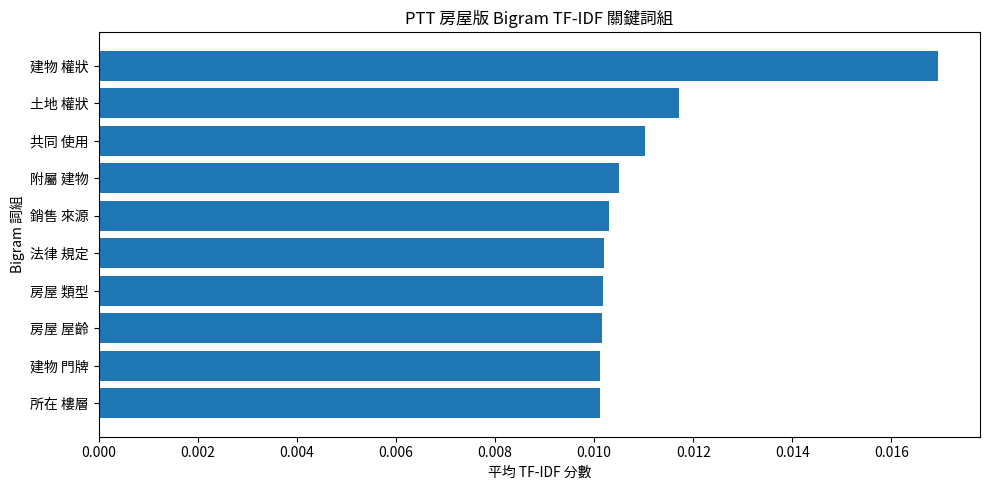

In [30]:
plot_df = bigram_keywords.head(10).iloc[::-1]

plt.figure(figsize=(10, 5))
plt.barh(plot_df['ngram_word'], plot_df['tfidf_score'])
plt.title('PTT 房屋版 Bigram TF-IDF 關鍵詞組')
plt.xlabel('平均 TF-IDF 分數')
plt.ylabel('Bigram 詞組')
plt.tight_layout()
plt.show()

In [31]:
# 關鍵詞共現分析
# 取前 30 個高頻詞，計算同篇文章中共同出現的詞彙配對。
from itertools import combinations

co_words = [w for w, c in word_counts.most_common(30)]
co_word_set = set(co_words)
co_counter = Counter()

for token_str in articles_cleaned['tokens_str'].fillna(''):
    words = list(set(token_str.split()) & co_word_set)
    for w1, w2 in combinations(sorted(words), 2):
        co_counter[(w1, w2)] += 1

cooccurrence_edges = pd.DataFrame(
    [(w1, w2, weight) for (w1, w2), weight in co_counter.items() if weight >= 2],
    columns=['word1', 'word2', 'weight']
).sort_values('weight', ascending=False)

display(cooccurrence_edges.head(20))

,word1,word2,weight
189,屋齡,房屋,2009
180,實價登錄,房屋,1992
159,坪數,房屋,1991
147,土地,房屋,1990
162,坪數,格局,1990
157,坪數,屋齡,1988
192,屋齡,格局,1979
206,房屋,格局,1957
5,交通,房屋,1954
197,建物,房屋,1943


### RQ4 前置分析：房市政策是否是熱門討論主題？

本段使用政策關鍵詞統計、政策詞時間趨勢與政策詞共現分析，檢查房市政策是否在 PTT 房屋版中形成熱門討論主題。  
這裡是前置分析區，後面的 RQ4 Summary 只會整理顯示本段產生的結果。

In [32]:
# =========================
# RQ4-1：政策詞典統計
# =========================

policy_words = [
    '新青安', '央行限貸', '限貸', '房地合一稅',
    '房貸利率', '貸款成數', '升息', '降息',
    '實價登錄', '打房', '貸款'
]

policy_counts = []

for word in policy_words:
    article_count = articles_cleaned['tokens_str'].fillna('').apply(
        lambda x: word in x.split()
    ).sum()

    policy_counts.append({
        'policy_word': word,
        'article_count': article_count,
        'article_ratio': article_count / len(articles_cleaned)
    })

policy_df = pd.DataFrame(policy_counts).sort_values(
    'article_count',
    ascending=False
).reset_index(drop=True)

display(policy_df)

,policy_word,article_count,article_ratio
0,實價登錄,2192,0.223400
1,貸款,1328,0.135344
2,新青安,538,0.054831
3,限貸,296,0.030167
4,打房,292,0.029759
5,貸款成數,140,0.014268
6,房貸利率,105,0.010701
7,降息,99,0.010090
8,房地合一稅,73,0.007440
9,升息,64,0.006523


In [33]:
# =========================
# RQ4-2：政策詞時間趨勢
# =========================

articles_cleaned['post_datetime'] = pd.to_datetime(
    articles_cleaned['post_date'],
    errors='coerce'
)

articles_cleaned['post_month'] = articles_cleaned['post_datetime'].dt.to_period('M').astype(str)

policy_trend_rows = []

for word in policy_words:
    temp = articles_cleaned[
        articles_cleaned['tokens_str'].fillna('').apply(lambda x: word in x.split())
    ].copy()

    monthly_count = temp.groupby('post_month').size().reset_index(name='count')
    monthly_count['policy_word'] = word

    policy_trend_rows.append(monthly_count)

policy_trend_df = pd.concat(policy_trend_rows, ignore_index=True)

display(policy_trend_df.head(20))

,post_month,count,policy_word
0,2025-06,63,新青安
1,2025-07,34,新青安
2,2025-08,117,新青安
3,2025-09,117,新青安
4,2025-10,25,新青安
5,2025-11,46,新青安
6,2025-12,6,新青安
7,2026-01,46,新青安
8,2026-02,37,新青安
9,2026-03,30,新青安


In [34]:
# =========================
# RQ4-3：政策詞共現分析
# =========================

from collections import Counter
from itertools import combinations

# 想觀察政策詞和哪些房市詞一起出現
focus_words = policy_words + [
    '房價', '買房', '首購', '自備款', '利率',
    '房市', '預售屋', '建商', '坪數', '車位',
    '實價登錄', '市場', '負擔'
]

focus_word_set = set(focus_words)
policy_co_counter = Counter()

for token_str in articles_cleaned['tokens_str'].fillna(''):
    words = list(set(token_str.split()) & focus_word_set)

    for w1, w2 in combinations(sorted(words), 2):
        # 至少其中一個詞是政策詞，才納入
        if w1 in policy_words or w2 in policy_words:
            policy_co_counter[(w1, w2)] += 1

policy_cooccurrence_df = pd.DataFrame(
    [
        {'word1': pair[0], 'word2': pair[1], 'weight': count}
        for pair, count in policy_co_counter.items()
    ]
).sort_values('weight', ascending=False).reset_index(drop=True)

display(policy_cooccurrence_df.head(20))

,word1,word2,weight
0,坪數,實價登錄,1925
1,實價登錄,車位,1844
2,實價登錄,市場,496
3,房價,貸款,483
4,實價登錄,預售屋,412
5,市場,貸款,368
6,房市,貸款,359
7,買房,貸款,350
8,利率,貸款,308
9,新青安,貸款,301


### RQ2 前置分析：文章、推文與面向式情緒分析

本段使用 SnowNLP 進行情緒分析，分成四個部分：文章情緒分析、推文情緒分析、PTT 推 / 噓 / → 分布，以及面向式情緒分析。  
這裡是 RQ2 的前置計算區，後面的 RQ2 Summary 只會整理顯示本段產生的結果。

In [75]:
# RQ2 情緒分析前置與計算
from snownlp import SnowNLP
import pandas as pd
import numpy as np

# =========================
# RQ2：情緒分析函數
# =========================

def get_sentiment_score(text):
    """
    SnowNLP 情緒分數：
    越接近 1 越正面，越接近 0 越負面。
    為避免文章太長造成速度過慢，只取前 1000 字。
    """
    try:
        if not isinstance(text, str) or len(text.strip()) == 0:
            return np.nan
        return SnowNLP(text[:1000]).sentiments
    except Exception:
        return np.nan


def sentiment_label(score):
    """
    將 SnowNLP 分數轉成正面 / 中立 / 負面。
    """
    if pd.isna(score):
        return '無法判斷'
    if score >= 0.6:
        return '正面'
    if score >= 0.4:
        return '中立'
    return '負面'


# =========================
# RQ2-1：文章情緒分析
# =========================

if 'articles_cleaned' not in globals():
    raise NameError("找不到 articles_cleaned，請先執行文章清理與斷詞的 cell。")

if 'clean_text' not in articles_cleaned.columns:
    raise KeyError("articles_cleaned 找不到 clean_text 欄位，請先完成文字清理。")

if len(articles_cleaned) == 0:
    article_sentiment_distribution = pd.DataFrame(columns=['sentiment', 'count', 'ratio'])
    print("articles_cleaned 是空的，略過文章情緒分析。")
else:
    if 'sentiment_score' not in articles_cleaned.columns or 'sentiment_label' not in articles_cleaned.columns:
        print("開始計算文章情緒...")
        articles_cleaned['sentiment_score'] = articles_cleaned['clean_text'].apply(get_sentiment_score)
        articles_cleaned['sentiment_label'] = articles_cleaned['sentiment_score'].apply(sentiment_label)

    article_sentiment_distribution = (
        articles_cleaned['sentiment_label']
        .value_counts()
        .reset_index()
    )

    article_sentiment_distribution.columns = ['sentiment', 'count']
    article_sentiment_distribution['ratio'] = (
        article_sentiment_distribution['count'] / len(articles_cleaned)
    )

print("--- 文章情緒分析 ---")
display(article_sentiment_distribution)


# 保留舊變數名稱，讓後面的圖表 code 可以繼續使用
sentiment_distribution = article_sentiment_distribution[['sentiment', 'count']].copy()


# =========================
# RQ2-2：推文情緒分析，抽樣 10,000 則
# =========================

if 'comments_cleaned' not in globals():
    print("找不到 comments_cleaned，建立空的推文資料表並略過推文情緒分析。")
    comments_cleaned = pd.DataFrame()

if 'clean_comment_text' in comments_cleaned.columns:
    comment_text_col = 'clean_comment_text'
elif 'comment_text' in comments_cleaned.columns:
    comment_text_col = 'comment_text'
elif 'cmtContent' in comments_cleaned.columns:
    comment_text_col = 'cmtContent'
else:
    comment_text_col = None

if comment_text_col is None or len(comments_cleaned) == 0:
    comments_sample = pd.DataFrame()
    comment_sentiment_distribution = pd.DataFrame(columns=['sentiment', 'count', 'ratio'])
    print("找不到推文文字欄位或 comments_cleaned 為空，略過推文情緒分析。")
else:
    sample_size = min(10000, len(comments_cleaned))
    comments_sample = comments_cleaned.sample(sample_size, random_state=42).copy()

    comments_sample['comment_sentiment_score'] = (
        comments_sample[comment_text_col].apply(get_sentiment_score)
    )
    comments_sample['comment_sentiment_label'] = (
        comments_sample['comment_sentiment_score'].apply(sentiment_label)
    )

    comment_sentiment_distribution = (
        comments_sample['comment_sentiment_label']
        .value_counts()
        .reset_index()
    )

    comment_sentiment_distribution.columns = ['sentiment', 'count']
    comment_sentiment_distribution['ratio'] = (
        comment_sentiment_distribution['count'] / len(comments_sample)
    )

print("--- 推文情緒分析 ---")
display(comment_sentiment_distribution)


# =========================
# RQ2-3：PTT 推 / 噓 / → 分布
# =========================

if 'comment_type' in comments_cleaned.columns:
    comment_type_col = 'comment_type'
elif 'cmtStatus' in comments_cleaned.columns:
    comment_type_col = 'cmtStatus'
else:
    comment_type_col = None

if comment_type_col is None or len(comments_cleaned) == 0:
    comment_type_distribution = pd.DataFrame(columns=['comment_type', 'count', 'ratio'])
    print("找不到推文類型欄位，略過推 / 噓 / → 分析。")
else:
    comment_type_distribution = (
        comments_cleaned[comment_type_col]
        .value_counts()
        .reset_index()
    )

    comment_type_distribution.columns = ['comment_type', 'count']
    comment_type_distribution['ratio'] = (
        comment_type_distribution['count'] / len(comments_cleaned)
    )

print("--- PTT 推 / 噓 / → 分布 ---")
display(comment_type_distribution)


# =========================
# RQ2-4：Aspect-based Sentiment Analysis
# =========================

aspects = {
    '房價': ['房價', '價格', '漲', '跌', '行情', '市場'],
    '買房': ['買房', '購屋', '首購', '首購族', '自備款', '頭期款', '負擔'],
    '政策': ['新青安', '限貸', '央行限貸', '打房', '房地合一稅', '政策'],
    '貸款': ['貸款', '房貸', '房貸利率', '利率', '貸款成數', '升息', '降息']
}

aspect_rows = []

if comment_text_col is None or len(comments_sample) == 0 or 'comment_sentiment_label' not in comments_sample.columns:
    for aspect_name in aspects.keys():
        aspect_rows.append({
            'aspect': aspect_name,
            'sample_count': 0,
            'positive_count': 0,
            'neutral_count': 0,
            'negative_count': 0,
            'positive_ratio': 0,
            'neutral_ratio': 0,
            'negative_ratio': 0
        })
else:
    for aspect_name, keywords in aspects.items():
        mask = comments_sample[comment_text_col].fillna('').apply(
            lambda text: any(keyword in str(text) for keyword in keywords)
        )

        aspect_df = comments_sample[mask].copy()

        if len(aspect_df) == 0:
            aspect_rows.append({
                'aspect': aspect_name,
                'sample_count': 0,
                'positive_count': 0,
                'neutral_count': 0,
                'negative_count': 0,
                'positive_ratio': 0,
                'neutral_ratio': 0,
                'negative_ratio': 0
            })
            continue

        sentiment_counts = aspect_df['comment_sentiment_label'].value_counts()

        positive_count = sentiment_counts.get('正面', 0)
        neutral_count = sentiment_counts.get('中立', 0)
        negative_count = sentiment_counts.get('負面', 0)

        aspect_rows.append({
            'aspect': aspect_name,
            'sample_count': len(aspect_df),
            'positive_count': positive_count,
            'neutral_count': neutral_count,
            'negative_count': negative_count,
            'positive_ratio': positive_count / len(aspect_df),
            'neutral_ratio': neutral_count / len(aspect_df),
            'negative_ratio': negative_count / len(aspect_df)
        })

aspect_sentiment_df = pd.DataFrame(aspect_rows)

print("--- 面向式情緒分析 ---")
display(aspect_sentiment_df)

--- 文章情緒分析 ---


,sentiment,count,ratio
0,負面,8801,0.896963
1,正面,921,0.093865
2,中立,90,0.009172


--- 推文情緒分析 ---


,sentiment,count,ratio
0,負面,6033,0.6033
1,正面,2595,0.2595
2,中立,1372,0.1372


--- PTT 推 / 噓 / → 分布 ---


,comment_type,count,ratio
0,→,250715,0.589599
1,推,157496,0.370378
2,噓,17019,0.040023


--- 面向式情緒分析 ---


,aspect,sample_count,positive_count,neutral_count,negative_count,positive_ratio,neutral_ratio,negative_ratio
0,房價,623,93,59,471,0.149278,0.094703,0.756019
1,買房,262,54,36,172,0.206107,0.137405,0.656489
2,政策,179,53,28,98,0.296089,0.156425,0.547486
3,貸款,225,44,32,149,0.195556,0.142222,0.662222


In [46]:
# 儲存文章情緒結果
articles_cleaned.to_csv(
    'data_processed/ptt_home_sale_articles_with_sentiment.csv',
    index=False,
    encoding='utf-8-sig'
)

# 儲存推文抽樣情緒結果
comments_sample.to_csv(
    'data_processed/ptt_home_sale_comments_sample_with_sentiment.csv',
    index=False,
    encoding='utf-8-sig'
)

# 儲存 RQ2 統計結果
article_sentiment_distribution.to_csv(
    'data_processed/rq2_article_sentiment_distribution.csv',
    index=False,
    encoding='utf-8-sig'
)

comment_sentiment_distribution.to_csv(
    'data_processed/rq2_comment_sentiment_distribution.csv',
    index=False,
    encoding='utf-8-sig'
)

aspect_sentiment_df.to_csv(
    'data_processed/rq2_aspect_sentiment.csv',
    index=False,
    encoding='utf-8-sig'
)

In [47]:
# 推文類型分析
# 修正：檢索正確的欄位名稱 'cmtStatus'
if 'cmtStatus' in comments_cleaned.columns and len(comments_cleaned) > 0:
    comment_type_distribution = comments_cleaned['cmtStatus'].value_counts().reset_index()
    comment_type_distribution.columns = ['comment_type', 'count']
    comment_type_distribution['ratio'] = comment_type_distribution['count'] / comment_type_distribution['count'].sum()
else:
    comment_type_distribution = pd.DataFrame(columns=['comment_type', 'count', 'ratio'])

display(comment_type_distribution)

,comment_type,count,ratio
0,→,250715,0.589599
1,推,157496,0.370378
2,噓,17019,0.040023


**圖表解釋：sentiment_distribution.png**

這張圖代表文章文字經 SnowNLP 判斷後的情緒分布。若負面比例較高，可能表示網友對高房價、貸款壓力、租金負擔或政策效果感到不滿；若中立比例較高，可能代表房屋版有許多資訊交換、行情討論與理性分析文。

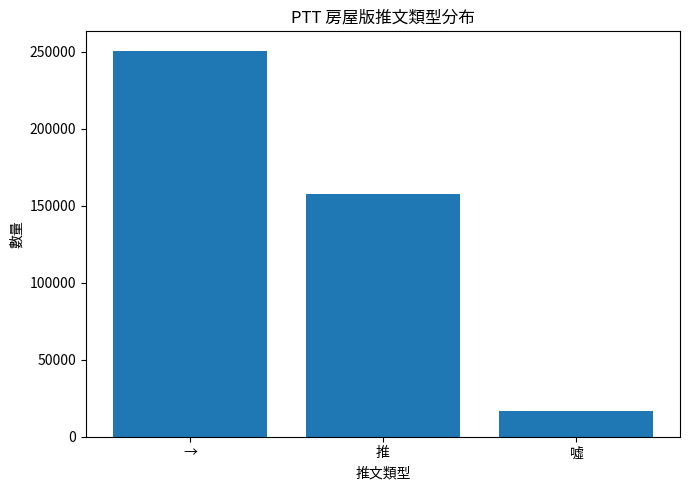

In [55]:
# 5. 推文類型分布圖
plt.figure(figsize=(7, 5))
if len(comment_type_distribution) > 0:
    plt.bar(comment_type_distribution['comment_type'], comment_type_distribution['count'])
else:
    plt.text(0.5, 0.5, '無推文類型資料', ha='center', va='center')
plt.title('PTT 房屋版推文類型分布')
plt.xlabel('推文類型')
plt.ylabel('數量')
plt.tight_layout()
plt.savefig('figures/comment_type_distribution.png', dpi=300)
plt.show()

### Transformer (BERT) 情緒分析與 SnowNLP 比較
SnowNLP 是基於機率的傳統模型，而 BERT 是基於深度學習的語言模型，對語意理解較強。由於 BERT 執行較慢，我們抽樣 200 筆資料進行比較。

In [48]:
from transformers import pipeline
import torch

# 載入預訓練的中文情緒分析模型
# 使用專門處理中文情緒分類的模型
model_name = "IDEA-CCNL/Erlangshen-Roberta-110M-Sentiment"
sentiment_pipeline = pipeline("sentiment-analysis", model=model_name)

# 抽樣 200 筆進行比較以節省運算時間
sample_size = 200
compare_df = articles_cleaned.sample(n=min(sample_size, len(articles_cleaned)), random_state=42).copy()

def get_bert_sentiment(text):
    try:
        # BERT 限制長度通常為 512 tokens
        res = sentiment_pipeline(text[:300])[0]
        # 轉換標籤格式以對齊比較
        return res['label'], res['score']
    except:
        return "Error", 0.0

print("正在執行 BERT 情緒分析...")
compare_df['bert_result'] = compare_df['clean_text'].apply(get_bert_sentiment)
compare_df['bert_label'] = compare_df['bert_result'].apply(lambda x: '正面' if x[0] == 'Positive' or x[0] == '1' or x[0] == 'Label_1' else '負面')

# 統計比較
comparison = pd.crosstab(compare_df['sentiment_label'], compare_df['bert_label'])
print("--- SnowNLP vs BERT 分類對照表 ---")
display(comparison)

# 顯示部分不一致的案例供人工檢查
mismatch = compare_df[compare_df['sentiment_label'] != compare_df['bert_label']][['title', 'sentiment_label', 'bert_label']].head(10)
print("--- 分類不一致的案例 ---")
display(mismatch)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

正在執行 BERT 情緒分析...
--- SnowNLP vs BERT 分類對照表 ---


bert_label,正面,負面
sentiment_label,,
中立,1,0
正面,19,1
負面,132,47


--- 分類不一致的案例 ---


,title,sentiment_label,bert_label
4001,[新聞]社子島開發惹議！市民恐多背債7.3萬北,負面,正面
1569,Re:[閒聊]預售屋禁轉有什麼好處？,負面,正面
7573,Re:[心得]買透天別墅~坪數一樣價值差很大,負面,正面
1791,Re:[閒聊]下個世代準備考慮移居海外吧,負面,正面
4184,Re:[請益]台灣2025年GDP預測繼續噴?,負面,正面
4851,[新聞]輝達進駐北士科案 蔣萬安：已清楚表達,負面,正面
9218,[賣/桃園/桃園]藝文慈文國小旁合輝景觀四房車位,負面,正面
6210,[閒聊]Zack:財產權不該高於居住正義的人權？,負面,正面
7743,[賣/台北/中山]『凱旋大樓』主+附４２.８坪使用空間有電梯,負面,正面
7089,[新聞]預售屋供給近乎真空 高雄美術館去年房,負面,正面


### 檢視 SnowNLP 與 BERT 情緒判斷不一致的詳細內容
我們將抽出的不一致案例進行全文（部分）檢視，以判斷哪一個模型的預測更符合真實語境。

In [49]:
import pandas as pd

# 篩選出不一致的資料並與原始 cleaned 資料合併以取得完整內容
mismatch_details = compare_df[compare_df['sentiment_label'] != compare_df['bert_label']].copy()

# 整理顯示格式
print(f"共有 {len(mismatch_details)} 筆不一致案例。")

# 顯示前 15 筆詳細內容供人工比對
for i, row in mismatch_details.head(15).iterrows():
    print(f"【標題】: {row['title']}")
    print(f"【SnowNLP】: {row['sentiment_label']} (分數: {row['sentiment_score']:.2f})")
    print(f"【BERT】: {row['bert_label']} (模型標籤: {row['bert_result'][0]}, 分數: {row['bert_result'][1]:.2f})")
    print(f"【部分內文】: {row['clean_text'][:500]}...")
    print("-" * 50)

共有 134 筆不一致案例。
【標題】: [新聞]社子島開發惹議！市民恐多背債7.3萬北
【SnowNLP】: 負面 (分數: 0.00)
【BERT】: 正面 (模型標籤: Positive, 分數: 0.99)
【部分內文】: 新聞 社子島開發惹議 市民恐多背債   萬北 社子島開發惹議 市民恐多背債   萬 北市府澄清回應          中時即時  張珈瑄   社子島自救會 日早上到北市府遞交陳情書 抗議社子島計畫將讓北市自償性公共債務暴 增   億元 市民多背債   萬元  張珈瑄攝   台北市政府 日舉辦 社子島地區區段徵收案 首場土地協議價購會議 社子島自救會到場 陳抗程序違法  日早上又到北市府前抗議並遞交陳情書 社子島計畫將讓北市自償性公共 債務暴增   億元 市民多背債   萬元 還要求拆遷居民以 萬元購入安置宅 北市 地政局表示 開發所需經費由北市實施平均地權基金支應 不應以財務作唯一考量 另安置 住宅以成本價配售 經濟弱勢最高發給  的租金補貼並保障租期 年 以達戶戶安置目 標   社子島自救會 台灣人權促進會 環境權保障基金會 以及小民參政歐巴桑聯盟 台灣基進  台灣綠黨 時代力量眾人齊喊 本土小黨來監督 停止社子島大迫遷  資深媒體人馮光 遠也到場聲援 抗議社子島計畫將讓台北市自償性公共債務暴增   億元 每位市民將多 背債   萬元 呼籲台北市長蔣萬安停止社子島大迫遷計畫   環境...
--------------------------------------------------
【標題】: Re:[閒聊]預售屋禁轉有什麼好處？
【SnowNLP】: 負面 (分數: 0.00)
【BERT】: 正面 (模型標籤: Positive, 分數: 0.83)
【部分內文】: 閒聊 預售屋禁轉有什麼好處  其實就是堵住看別人賺錢不平衡的人 自己觀望沒買到在不爽  但不能換約有什麼問題呢 少了不少投機客沒錯   但投資客都是有能力交屋才買 一定賺夠才賣   自住客買下去工作 生涯 收入有改變時 導致要賣屋 只能交屋再賣或賠      貸款出問題時只能用二親等換約貸款 或是賠      價格漲跌建商說的算 今天賣 萬明天漲 萬沒人干擾 降價賣時候也沒投資客甘願 認賠比降價    產生任何違約建商現賺...
----------------

### 深度分析：SnowNLP 與 BERT 分數差異較大案例檢視

我們針對 SnowNLP 判定為「負面」(0.00) 但 BERT 判定為「正面」的高信心案例進行抽樣。這類案例通常包含大量的法律免責聲明、技術性買賣術語（如：處分、違約、扣押），導致傳統模型誤判。

In [50]:
# 篩選差異極大案例：SnowNLP < 0.1 且 BERT 為正面且信心度高
extreme_mismatches = compare_df[
    (compare_df['sentiment_score'] < 0.1) &
    (compare_df['bert_label'] == '正面')
].sort_values(by='sentiment_score').head(15)

print(f"找到 {len(extreme_mismatches)} 筆極大差異案例。\n")

for i, row in extreme_mismatches.iterrows():
    print(f"【文章標題】: {row['title']}")
    print(f"【SnowNLP 分數】: {row['sentiment_score']:.4f} (判定: {row['sentiment_label']})")
    print(f"【BERT 信心度】: {row['bert_result'][1]:.4f} (判定: {row['bert_label']})")
    print(f"【關鍵內容片段】: {row['clean_text'][:300]}...")
    print("="*80)

找到 15 筆極大差異案例。

【文章標題】: [新聞]社子島開發惹議！市民恐多背債7.3萬北
【SnowNLP 分數】: 0.0000 (判定: 負面)
【BERT 信心度】: 0.9859 (判定: 正面)
【關鍵內容片段】: 新聞 社子島開發惹議 市民恐多背債   萬北 社子島開發惹議 市民恐多背債   萬 北市府澄清回應          中時即時  張珈瑄   社子島自救會 日早上到北市府遞交陳情書 抗議社子島計畫將讓北市自償性公共債務暴 增   億元 市民多背債   萬元  張珈瑄攝   台北市政府 日舉辦 社子島地區區段徵收案 首場土地協議價購會議 社子島自救會到場 陳抗程序違法  日早上又到北市府前抗議並遞交陳情書 社子島計畫將讓北市自償性公共 債務暴增   億元 市民多背債   萬元 還要求拆遷居民以 萬元購入安置宅 北市 地政局表示 開發所需經費由北市實施平均地權基金支應 不應以財務作唯一考量 另安置...
【文章標題】: Re:[心得]買透天別墅~坪數一樣價值差很大
【SnowNLP 分數】: 0.0000 (判定: 負面)
【BERT 信心度】: 0.9837 (判定: 正面)
【關鍵內容片段】: 心得 買透天別墅 坪數一樣價值差很大 交易量較大的非豪宅透天主要分五種  在同一地段 登記地坪同為 坪的透天  不同型態下價格與真正可用土地 肉地 差異非常明顯     社區型地下停車透天  假設價格為   因地下室 車道與公設分攤比例高  實際可用土地約   坪  此類產品以建物價值為主 土地持分最弱     社區型門前停車透天  價格約          可門前停車 但車道多屬社區持分  實地坪約   坪  土地價值略優於地下停車型 但仍非完整持有     社區型新加坡式透天  價格約          公設相對少 土地使用效率提高  實地坪約   坪  自住舒適度佳 但仍有社區道路分攤 ...
【文章標題】: [新聞]輝達進駐北士科案　蔣萬安：已清楚表達
【SnowNLP 分數】: 0.0000 (判定: 負面)
【BERT 信心度】: 0.9906 (判定: 正面)
【關鍵內容片段】: 新聞 輝達進駐北士科案 蔣萬安 已清楚表達 輝達進駐北士科案 蔣萬安 已清楚表達北市府立場             輝達台灣總部興建因用地取得問題卡關 北市

## 六、視覺化圖表

以下圖表都會儲存到 figures 資料夾。

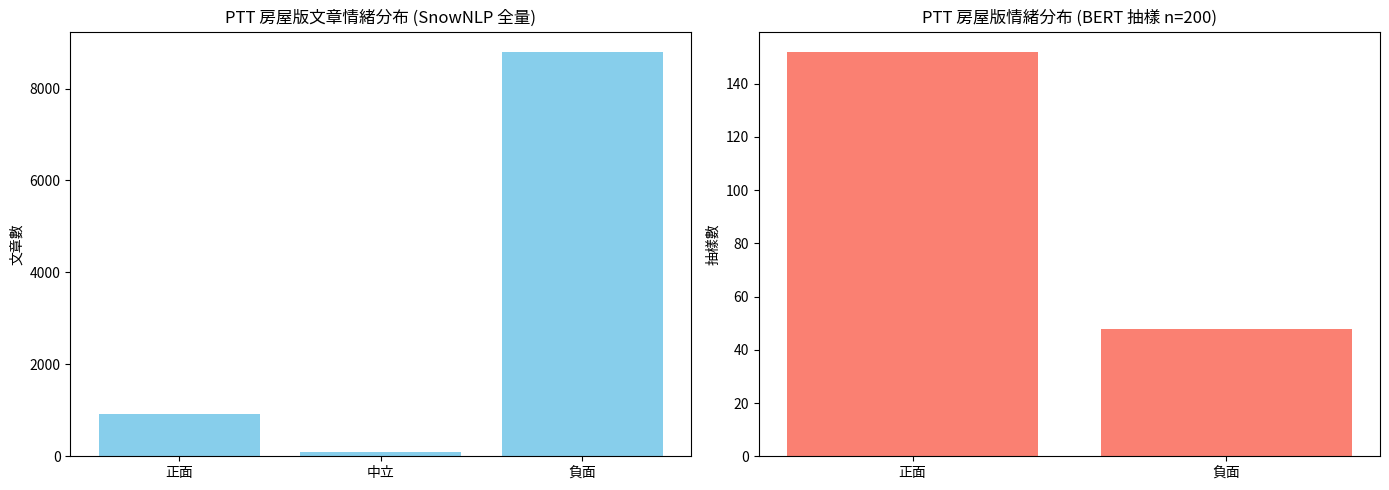

In [54]:
# 4. 情緒分布圖 - SnowNLP 與 BERT 比較
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot SnowNLP (Full Dataset)
if len(sentiment_distribution) > 0:
    order = ['正面', '中立', '負面', '無法判斷']
    plot_snownlp = sentiment_distribution.set_index('sentiment').reindex(order).dropna().reset_index()
    ax1.bar(plot_snownlp['sentiment'], plot_snownlp['count'], color='skyblue')
    ax1.set_title('PTT 房屋版文章情緒分布 (SnowNLP 全量)')
    ax1.set_ylabel('文章數')
else:
    ax1.text(0.5, 0.5, '無 SnowNLP 資料', ha='center', va='center')

# Plot BERT (Sampled Data)
if 'compare_df' in locals() and 'bert_label' in compare_df.columns:
    bert_dist = compare_df['bert_label'].value_counts().reset_index()
    bert_dist.columns = ['sentiment', 'count']
    ax2.bar(bert_dist['sentiment'], bert_dist['count'], color='salmon')
    ax2.set_title(f'PTT 房屋版情緒分布 (BERT 抽樣 n={len(compare_df)})')
    ax2.set_ylabel('抽樣數')
else:
    ax2.text(0.5, 0.5, '請先執行 BERT 分析區塊', ha='center', va='center')

plt.tight_layout()
plt.savefig('figures/sentiment_comparison.png', dpi=300)
plt.show()

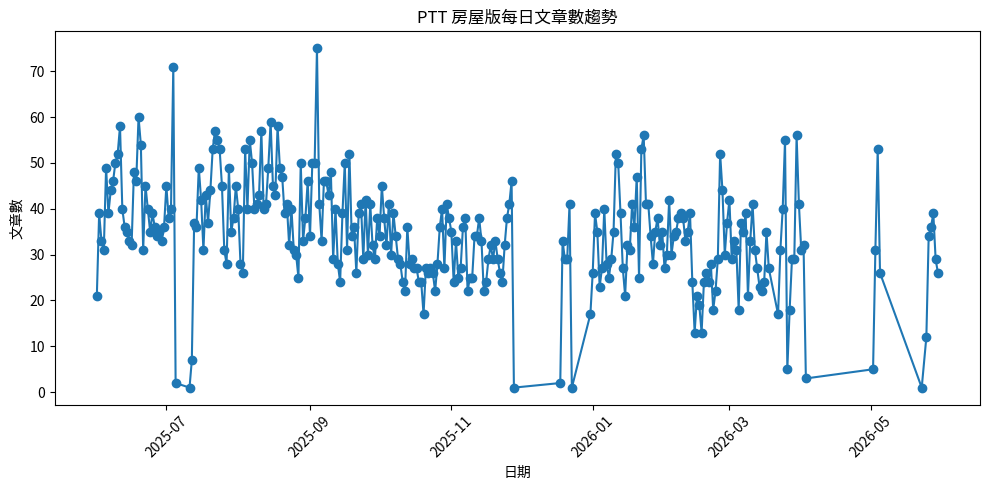

In [51]:
# 1. 每日文章數趨勢圖
plt.figure(figsize=(10, 5))
if len(articles_trend) > 0:
    plt.plot(articles_trend['post_day'], articles_trend['article_count'], marker='o')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, '無可用日期資料', ha='center', va='center')
plt.title('PTT 房屋版每日文章數趨勢')
plt.xlabel('日期')
plt.ylabel('文章數')
plt.tight_layout()
plt.savefig('figures/articles_trend.png', dpi=300)
plt.show()

**圖表解釋：comment_type_distribution.png**

這張圖代表推、噓、箭頭的數量比例。推文互動可用來觀察社群對文章觀點的反應方向。若箭頭比例高，可能表示討論偏補充資訊或中性互動；若噓文比例升高，可能反映房價、買房壓力、政策立場或投資觀點具有爭議。

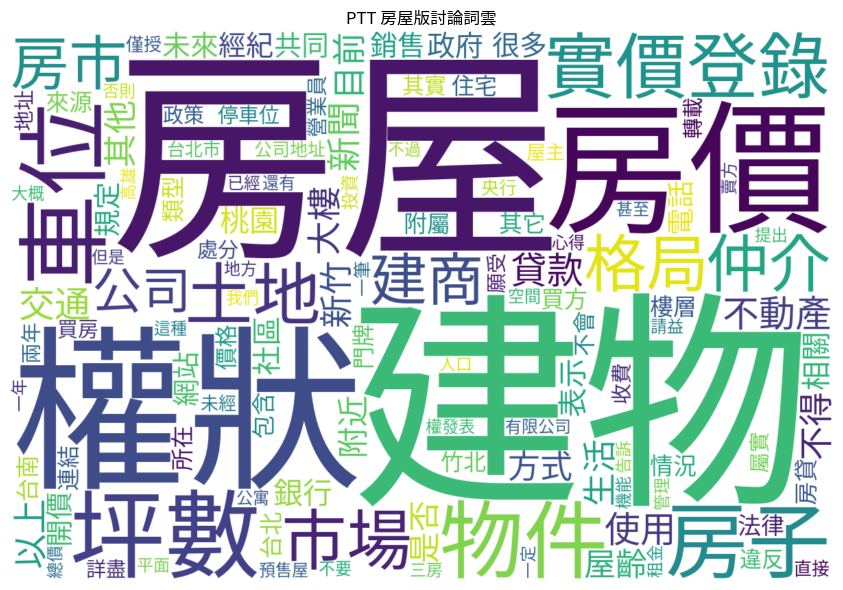

In [56]:
# 6. 詞雲圖
word_freq = dict(word_counts)

plt.figure(figsize=(10, 6))
if len(word_freq) > 0:
    wc = WordCloud(
        font_path=font_path,
        width=1200,
        height=800,
        background_color='white',
        max_words=120
    ).generate_from_frequencies(word_freq)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
else:
    plt.text(0.5, 0.5, '無詞雲資料', ha='center', va='center')
    plt.axis('off')
plt.title('PTT 房屋版討論詞雲')
plt.tight_layout()
plt.savefig('figures/wordcloud.png', dpi=300)
plt.show()

**圖表解釋：wordcloud.png**

這張圖以文字大小呈現詞彙出現頻率。字越大表示越常被討論。詞雲可快速看出 PTT 房屋版的核心語彙，例如房價、房貸、預售屋、租金、建商、限貸或政策相關詞，協助理解社群討論的主要輪廓。

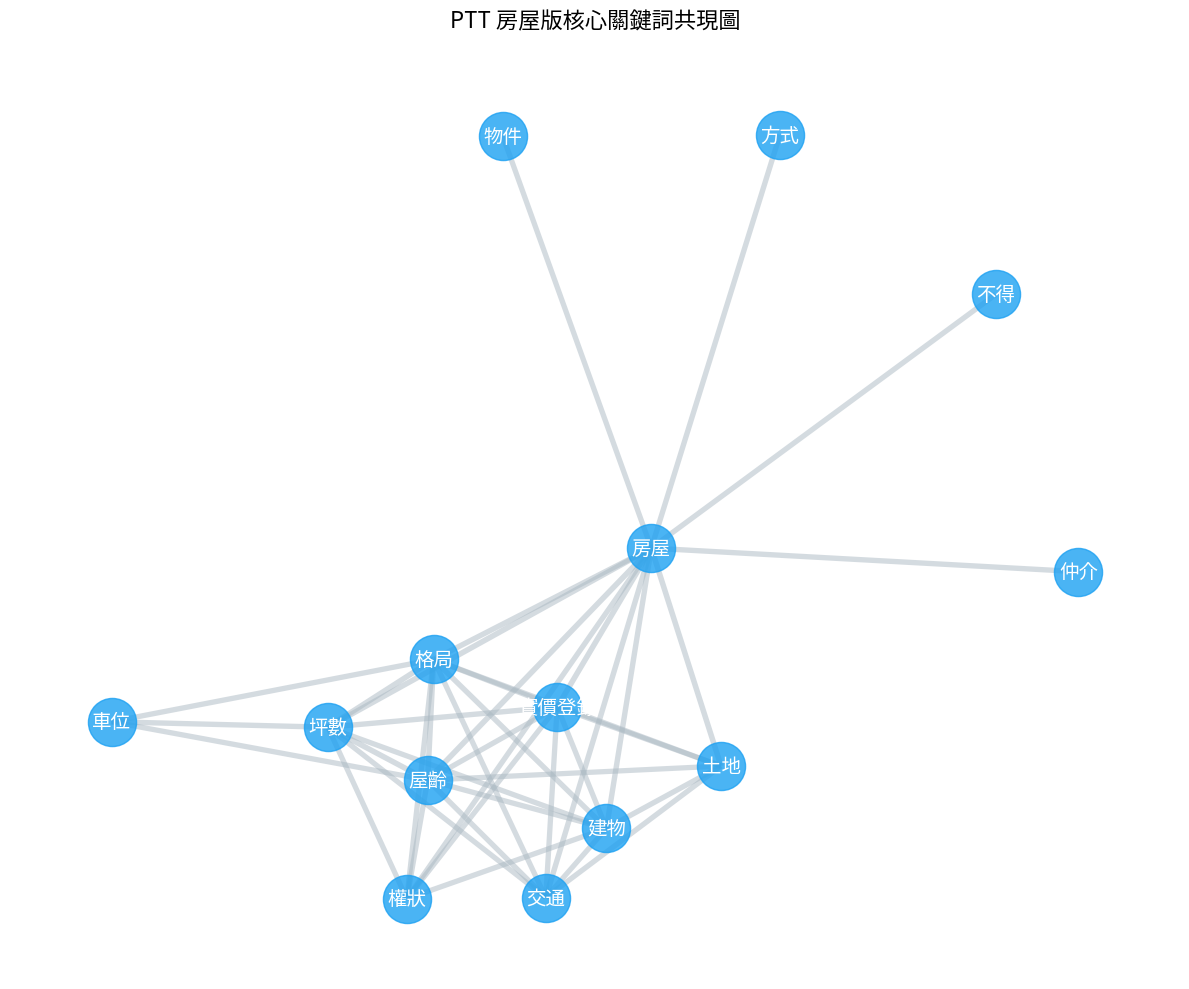

In [57]:
# 7. 關鍵詞共現網路圖 (核心關鍵詞簡化版)
import networkx as nx
import matplotlib.pyplot as plt

# 建立圖形物件
G = nx.Graph()

# 僅取前 40 條最強的連線，這能大幅減少視覺負擔
for _, row in cooccurrence_edges.head(40).iterrows():
    G.add_edge(row['word1'], row['word2'], weight=row['weight'])

plt.figure(figsize=(12, 10))
if G.number_of_nodes() > 0:
    # 調整佈局，k 值大表示推力大
    pos = nx.spring_layout(G, k=2.0, seed=42)

    # 1. 繪製邊緣 (設定較窄且明顯的連線)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    edge_widths = [w * 0.002 for w in weights]
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='#AAB8C2', alpha=0.5)

    # 2. 繪製節點 (統一大小，避免重疊)
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color='#1DA1F2', alpha=0.8)

    # 3. 繪製標籤 (加大字體並置中於節點)
    nx.draw_networkx_labels(G, pos, font_family='Noto Sans CJK JP',
                           font_size=14, font_weight='bold', font_color='white')

    plt.axis('off')
else:
    plt.text(0.5, 0.5, '無資料', ha='center', va='center')

plt.title('PTT 房屋版核心關鍵詞共現圖', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('figures/cooccurrence_network_final.png', dpi=300)
plt.show()

**圖表解釋：cooccurrence_network.png**

這張圖代表高頻詞之間在同篇文章共同出現的關係。節點是詞彙，連線表示兩個詞常一起出現。若房價與貸款、限貸、利率、預售屋或租金連在一起，表示網友常把價格變化與購屋條件、租屋負擔或政策措施一起討論。

## 七、主題模型分析 (Topic Modeling)
我們使用 LDA (傳統統計) 與 BERT 語意聚類 (深度學習) 來偵測 PTT 房屋版的主要討論主題。

In [58]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# 1. LDA 主題模型
n_topics = 5
tfv = CountVectorizer(max_df=0.9, min_df=5, token_pattern=r'(?u)\b\w+\b')
dtm = tfv.fit_transform(articles_cleaned['tokens_str'])

lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(dtm)

def get_lda_topics(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        topics[f'Topic {topic_idx+1}'] = top_features
    return pd.DataFrame(topics)

lda_top_words = get_lda_topics(lda, tfv.get_feature_names_out(), 10)
print("--- LDA 主題關鍵字 ---")
display(lda_top_words)

--- LDA 主題關鍵字 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
0,台北,建商,建物,房價,房子
1,公寓,政府,房屋,房市,貸款
2,社區,房東,權狀,市場,銀行
3,很多,新聞,坪數,建商,房價
4,請益,土地,車位,新聞,房貸
5,大樓,公司,物件,央行,買房
6,透天,住宅,實價登錄,人口,很多
7,地方,表示,格局,桃園,其實
8,房子,租金,仲介,表示,不要
9,生活,市府,不得,今年,不會


In [59]:
from sklearn.cluster import KMeans
from sentence_transformers import SentenceTransformer

# 2. BERT 語意聚類 (使用輕量化模型)
print("正在生成 BERT 嵌入向量 (取前 1000 筆樣本)...")
embed_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
sample_docs = articles_cleaned['clean_text'].head(1000).tolist()
embeddings = embed_model.encode(sample_docs, show_progress_bar=True)

# 使用 K-Means 進行聚類
kmeans = KMeans(n_clusters=n_topics, random_state=42)
clusters = kmeans.fit_predict(embeddings)

# 提取各類別的高頻詞
cluster_df = pd.DataFrame({'text': sample_docs, 'cluster': clusters})
bert_topics = {}
for i in range(n_topics):
    cluster_text = ' '.join(articles_cleaned.iloc[cluster_df[cluster_df['cluster'] == i].index]['tokens_str'])
    words = cluster_text.split()
    common = [w for w, c in Counter(words).most_common(10)]
    bert_topics[f'Cluster {i+1}'] = common

bert_top_words = pd.DataFrame(bert_topics)
print("\n--- BERT 聚類主題關鍵字 ---")
display(bert_top_words)

正在生成 BERT 嵌入向量 (取前 1000 筆樣本)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]


--- BERT 聚類主題關鍵字 ---


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
0,房市,房價,建物,人口,房價
1,年薪,銀行,房屋,少子,房屋
2,加薪,貸款,權狀,日本,社區
3,軍人,建商,車位,房價,建商
4,薪水,房市,坪數,房子,台北
5,不用,房子,實價登錄,政府,建物
6,小時,央行,物件,老人,房市
7,收入,市場,不得,小孩,台北市
8,普通,新青安,仲介,出生,新聞
9,下去,房貸,格局,不到,目前


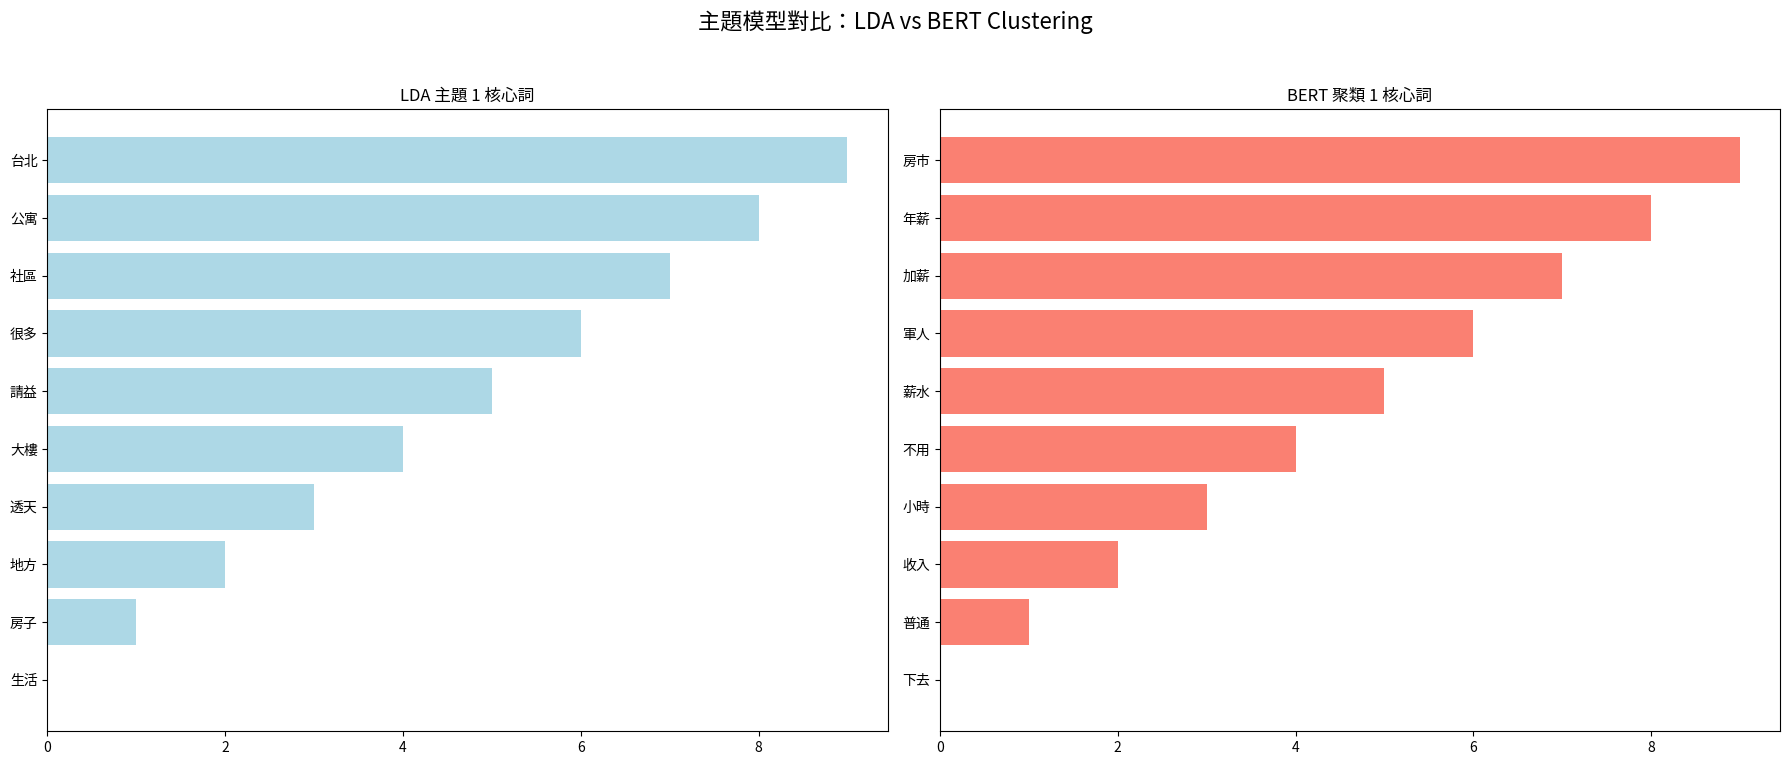

In [61]:
# 3. 視覺化比較
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 簡化視覺化：顯示兩個模型的第一個主題比較
ax1.barh(lda_top_words['Topic 1'][::-1], range(10), color='lightblue')
ax1.set_title('LDA 主題 1 核心詞')

ax2.barh(bert_top_words['Cluster 1'][::-1], range(10), color='salmon')
ax2.set_title('BERT 聚類 1 核心詞')

plt.suptitle('主題模型對比：LDA vs BERT Clustering', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 依照種子詞計算每篇文章偏向哪個主題

In [63]:
import pandas as pd
import numpy as np
from collections import Counter

# =========================
# RQ1：設定房市議題種子詞
# =========================

seed_topic_dict = {
    '房價市場': [
        '房價', '價格', '漲', '跌', '市場', '行情', '區域', '房市',
        '熱區', '蛋黃區', '蛋白區'
    ],
    '政策貸款': [
        '新青安', '限貸', '央行限貸', '房地合一稅', '房貸利率',
        '貸款', '貸款成數', '升息', '降息', '打房', '政策'
    ],
    '物件條件': [
        '建物', '權狀', '坪數', '車位', '屋齡', '樓層',
        '格局', '房屋', '物件', '土地', '公設'
    ],
    '買房負擔': [
        '買房', '首購', '首購族', '預算', '薪水', '負擔',
        '自備款', '頭期款', '購屋', '租金'
    ],
    '預售建商': [
        '預售屋', '建商', '代銷', '交屋', '成屋', '新建案',
        '銷售', '開案'
    ]
}

topic_names = list(seed_topic_dict.keys())

In [64]:
# =========================
# 根據 seed words 計算每篇文章的主題分數
# =========================

def assign_seed_topic(tokens_str):
    if pd.isna(tokens_str) or len(str(tokens_str).strip()) == 0:
        return '無法判斷'

    words = str(tokens_str).split()
    word_set = set(words)

    topic_scores = {}

    for topic_name, seed_words in seed_topic_dict.items():
        # 計算此文章命中多少該主題的 seed words
        score = sum(1 for w in seed_words if w in word_set)
        topic_scores[topic_name] = score

    max_score = max(topic_scores.values())

    if max_score == 0:
        return '其他'

    # 若有多個主題同分，取第一個最高分主題
    best_topic = max(topic_scores, key=topic_scores.get)
    return best_topic


articles_cleaned['seed_guided_topic'] = articles_cleaned['tokens_str'].apply(assign_seed_topic)

seed_topic_distribution = (
    articles_cleaned['seed_guided_topic']
    .value_counts()
    .reset_index()
)

seed_topic_distribution.columns = ['topic_name', 'article_count']
seed_topic_distribution['article_ratio'] = seed_topic_distribution['article_count'] / len(articles_cleaned)

display(seed_topic_distribution)

,topic_name,article_count,article_ratio
0,物件條件,3005,0.306258
1,房價市場,2941,0.299735
2,其他,1612,0.164289
3,政策貸款,1028,0.104770
4,買房負擔,738,0.075214
5,預售建商,488,0.049735


In [65]:
# =========================
# 每個主題顯示文章範例
# =========================

for topic_name in seed_topic_distribution['topic_name']:
    print(f"\n===== {topic_name}：文章範例 =====")

    sample_articles = (
        articles_cleaned[articles_cleaned['seed_guided_topic'] == topic_name]
        [['title', 'seed_guided_topic']]
        .head(5)
    )

    display(sample_articles)


===== 物件條件：文章範例 =====


,title,seed_guided_topic
4,[賣/新竹/香山]降價百達翡麗主附27坪採光大三房,物件條件
6,[閒聊]緊貼高中旁的建案,物件條件
9,[賣/新北/三重]西班牙水花園2+1房渡假宅,物件條件
10,[賣/新竹/竹北]縣三巨人精裝兩房平車,物件條件
11,[賣/新竹/竹北]實心甜2三房平車角間,物件條件



===== 房價市場：文章範例 =====


,title,seed_guided_topic
0,Re:[閒聊]科技進步對房價（探索裕隆城,房價市場
1,Re:[請益]政府如打房會沒選票是怎麼得出來的?,房價市場
2,[新聞]預售前10熱區桃園包辦6區「兩區」房價,房價市場
3,[情報]好房網5月份房價,房價市場
8,[心得]台幣升值房價漲？？,房價市場



===== 其他：文章範例 =====


...

,title,seed_guided_topic
12,[請益]為什麼打炒房依舊得不到選票?(民眾支持),政策貸款
18,[請益]高鐵附近預售屋,政策貸款
24,Re:[閒聊]台北新北什麼工作能買房,政策貸款
27,Re:[閒聊]台北新北什麼工作能買房,政策貸款
37,[請益]大家不想付租金就直接買一間不就好了?,政策貸款



===== 買房負擔：文章範例 =====


,title,seed_guided_topic
20,[閒聊]台北新北什麼工作能買房,買房負擔
21,[請益]總價700萬在高雄買哪裡有機會？,買房負擔
26,[新聞]月租2萬好心痛！存夠買房頭期款該衝一波,買房負擔
28,Re:[請益]總價700萬在高雄買哪裡有機會？,買房負擔
34,Re:[新聞]月租2萬好心痛！存夠買房頭期款該衝一波,買房負擔



===== 預售建商：文章範例 =====


,title,seed_guided_topic
5,[閒聊]屋主跟房仲拿簽約金?,預售建商
7,[閒聊]建商建照申請次數,預售建商
40,[閒聊]金龍快把新竹房仲都打死了吧…,預售建商
68,[請益]預售屋要求繳款2.5成合理嗎?,預售建商
80,Re:[心得]房價跌不跌的幾個想法,預售建商


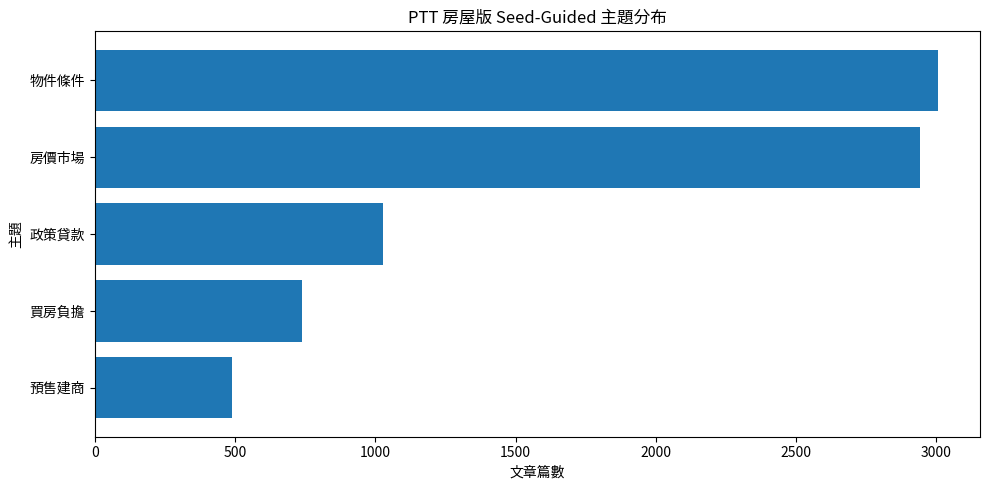

In [66]:
import matplotlib.pyplot as plt

plot_df = seed_topic_distribution[
    seed_topic_distribution['topic_name'] != '其他'
].iloc[::-1]

plt.figure(figsize=(10, 5))
plt.barh(plot_df['topic_name'], plot_df['article_count'])
plt.title('PTT 房屋版 Seed-Guided 主題分布')
plt.xlabel('文章篇數')
plt.ylabel('主題')
plt.tight_layout()
plt.show()

## 八、RQ 結果總覽


###    RQ1：PTT 房屋版最常討論哪些房市議題？

本題使用三種方式分析：

1. 高頻詞分析：觀察文章中最常出現的房市相關詞。
2. Bigram TF-IDF：觀察較具語意的房市詞組，例如「建物權狀」、「土地權狀」。
3. Seed-Guided Topic Analysis：根據研究目的設定主題類別，將文章歸類到「物件條件」、「房價市場」、「政策貸款」、「買房負擔」、「預售建商」等主題。

In [67]:
print("RQ1：PTT 房屋版最常討論哪些房市議題？")

print("\n1. 高頻詞前 10 名：")
display(top_words.head(10))

print("\n2. Bigram TF-IDF 前 10 名：")
display(bigram_keywords.head(10))

if 'seed_topic_distribution' in globals():
    print("\n3. Seed-Guided Topic Analysis：各主題文章數")
    display(seed_topic_distribution)
else:
    print("\n3. Seed-Guided Topic Analysis：尚未建立 seed_topic_distribution，請先執行 Seed-Guided 主題分析 cell。")

if 'seed_guided_topics_df' in globals():
    print("\n4. Seed-Guided Topic Analysis：各主題代表詞")
    display(seed_guided_topics_df)
else:
    print("\n4. Seed-Guided Topic Analysis：尚未建立 seed_guided_topics_df，請先執行 Seed-Guided 主題分析 cell。")


RQ1：PTT 房屋版最常討論哪些房市議題？

1. 高頻詞前 10 名：


,word,count
0,建物,9332
1,房屋,8974
2,權狀,5996
3,房價,5970
4,坪數,5852
5,車位,5560
6,物件,4731
7,房子,4528
8,實價登錄,4321
9,土地,3906



2. Bigram TF-IDF 前 10 名：


,ngram_word,tfidf_score
0,建物 權狀,0.016942
1,土地 權狀,0.011713
2,共同 使用,0.011031
3,附屬 建物,0.010494
4,銷售 來源,0.010307
5,法律 規定,0.010190
6,房屋 類型,0.010172
7,房屋 屋齡,0.010169
8,建物 門牌,0.010119
9,所在 樓層,0.010113



3. Seed-Guided Topic Analysis：各主題文章數


,topic_name,article_count,article_ratio
0,物件條件,3005,0.306258
1,房價市場,2941,0.299735
2,其他,1612,0.164289
3,政策貸款,1028,0.104770
4,買房負擔,738,0.075214
5,預售建商,488,0.049735



4. Seed-Guided Topic Analysis：尚未建立 seed_guided_topics_df，請先執行 Seed-Guided 主題分析 cell。


**RQ1 小結**

1. 從高頻詞結果來看，PTT 房屋版最常出現的詞包含「建物」、「房屋」、「權狀」、「房價」、
「坪數」、「車位」、「實價登錄」等，顯示討論內容集中在房屋物件資訊、產權資料與價格相關議題。

2. Bigram TF-IDF 進一步顯示，「建物權狀」、「土地權狀」、「附屬建物」、「房屋類型」、「房屋屋齡」、「所在樓層」等詞組具有代表性，表示文章不只討論房價，也大量涉及物件條件與交易資訊。

3. Seed-Guided Topic Analysis 則將文章歸類到「物件條件」、「房價市場」、「政策貸款」、「買房負擔」與「預售建商」等主題。整體而言，PTT 房屋版最主要的討論議題可整理為：物件條件、房價市場、政策貸款與買房負擔。

### RQ2: 網友對房價與買房的情緒偏正面、負面或中立？

RQ2：網友對房價與買房的情緒偏正面、負面或中立？

1. 文章情緒分布：


,sentiment,count,ratio
0,負面,8801,0.896963
1,正面,921,0.093865
2,中立,90,0.009172



2. 推文情緒分布，抽樣 10,000 則：


,sentiment,count,ratio
0,負面,6033,0.6033
1,正面,2595,0.2595
2,中立,1372,0.1372



3. PTT 推 / 噓 / → 分布：


,comment_type,count,ratio
0,→,250715,0.589599
1,推,157496,0.370378
2,噓,17019,0.040023



4. 面向式情緒分析：


,aspect,sample_count,positive_count,neutral_count,negative_count,positive_ratio,neutral_ratio,negative_ratio
0,房價,623,93,59,471,0.149278,0.094703,0.756019
1,買房,262,54,36,172,0.206107,0.137405,0.656489
2,政策,179,53,28,98,0.296089,0.156425,0.547486
3,貸款,225,44,32,149,0.195556,0.142222,0.662222



5. SnowNLP 與 BERT 情緒分布比較圖：


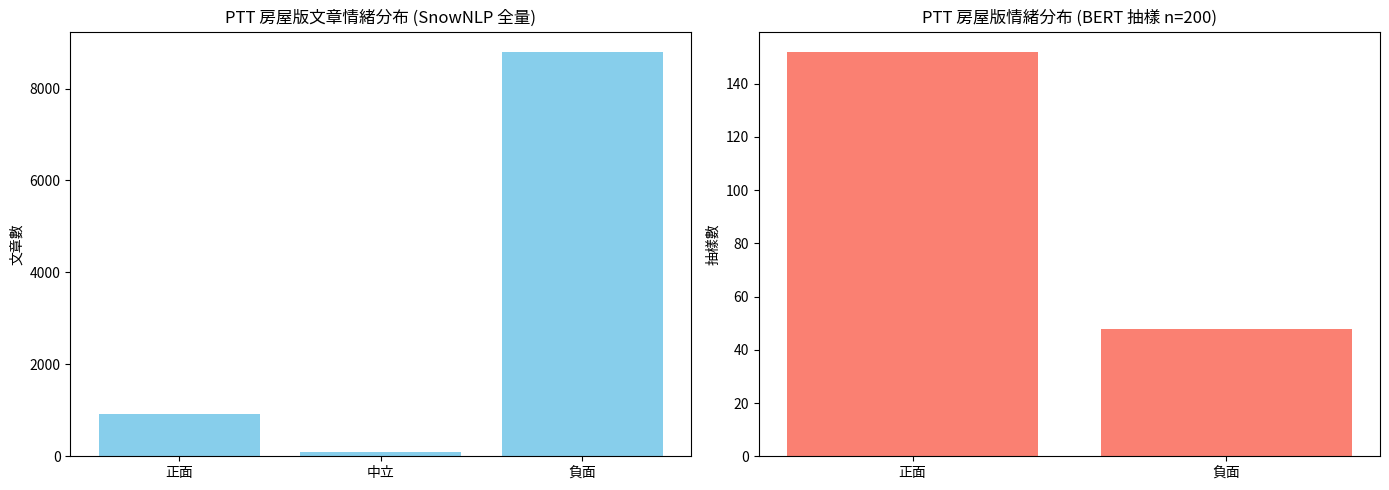


6. 文章情緒範例：


,title,sentiment_score,sentiment_label
0,Re:[閒聊]科技進步對房價（探索裕隆城,1.529388e-06,負面
1,Re:[請益]政府如打房會沒選票是怎麼得出來的?,0.000000e+00,負面
2,[新聞]預售前10熱區桃園包辦6區「兩區」房價,7.955645e-06,負面
3,[情報]好房網5月份房價,0.000000e+00,負面
4,[賣/新竹/香山]降價百達翡麗主附27坪採光大三房,6.538725e-04,負面
5,[閒聊]屋主跟房仲拿簽約金?,9.026680e-03,負面
6,[閒聊]緊貼高中旁的建案,4.408778e-07,負面
7,[閒聊]建商建照申請次數,4.755004e-02,負面
8,[心得]台幣升值房價漲？？,7.828426e-07,負面
9,[賣/新北/三重]西班牙水花園2+1房渡假宅,2.020606e-14,負面



7. 推文情緒範例：


,clean_comment_text,comment_sentiment_score,comment_sentiment_label
34567,擁有蛋黃老公寓 一堆身家根本很厚,0.107629,負面
263129,貪心住戶多多自食惡果,0.910919,正面
203934,薪資中位數 台灣還有另一群不在薪資表的人在影響,0.075392,負面
288928,垃圾山哪是在內科,0.095540,負面
115262,都更都可以持有毫無壓力但你如果是一坪百萬接盤俠當,0.005491,負面
233986,想太多了 低端在怎樣多也不會比絕大多數先進國家多,0.003359,負面
308396,最怕你抱不住,0.179631,負面
18615,現在是人工便宜以後呢 怎不說現在幫 繼續發展的在自掘墳,0.985394,正面
257370,魯空假套文 只漲不跌 從來沒聽過買房被套的,0.105457,負面
232297,買個 萬的房子很難嗎 漲爆,0.009005,負面


In [74]:
import os
import matplotlib.pyplot as plt

print("RQ2：網友對房價與買房的情緒偏正面、負面或中立？")

print("\n1. 文章情緒分布：")
display(article_sentiment_distribution)

print("\n2. 推文情緒分布，抽樣 10,000 則：")
display(comment_sentiment_distribution)

if 'comment_type_distribution' in globals():
    print("\n3. PTT 推 / 噓 / → 分布：")
    display(comment_type_distribution)

print("\n4. 面向式情緒分析：")
display(aspect_sentiment_df)


# =========================
# 5. SnowNLP 與 BERT 情緒分布比較圖
# =========================

print("\n5. SnowNLP 與 BERT 情緒分布比較圖：")

os.makedirs('figures', exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot SnowNLP，全量文章
if 'sentiment_distribution' in globals() and len(sentiment_distribution) > 0:
    order = ['正面', '中立', '負面', '無法判斷']
    plot_snownlp = (
        sentiment_distribution
        .set_index('sentiment')
        .reindex(order)
        .dropna()
        .reset_index()
    )

    ax1.bar(plot_snownlp['sentiment'], plot_snownlp['count'], color='skyblue')
    ax1.set_title('PTT 房屋版文章情緒分布 (SnowNLP 全量)')
    ax1.set_ylabel('文章數')
else:
    ax1.text(0.5, 0.5, '無 SnowNLP 資料', ha='center', va='center')
    ax1.set_title('PTT 房屋版文章情緒分布 (SnowNLP 全量)')

# Plot BERT，抽樣資料
if 'compare_df' in globals() and 'bert_label' in compare_df.columns:
    bert_dist = compare_df['bert_label'].value_counts().reset_index()
    bert_dist.columns = ['sentiment', 'count']

    # 固定順序：正面、負面
    bert_order = ['正面', '負面']
    bert_dist = (
        bert_dist
        .set_index('sentiment')
        .reindex(bert_order)
        .dropna()
        .reset_index()
    )

    ax2.bar(bert_dist['sentiment'], bert_dist['count'], color='salmon')
    ax2.set_title(f'PTT 房屋版情緒分布 (BERT 抽樣 n={len(compare_df)})')
    ax2.set_ylabel('抽樣數')
else:
    ax2.text(0.5, 0.5, '請先執行 BERT 分析區塊', ha='center', va='center')
    ax2.set_title('PTT 房屋版情緒分布 (BERT 抽樣)')

plt.tight_layout()
plt.savefig('figures/sentiment_comparison.png', dpi=300)
plt.show()


print("\n6. 文章情緒範例：")
display(articles_cleaned[['title', 'sentiment_score', 'sentiment_label']].head(10))

print("\n7. 推文情緒範例：")
display(comments_sample[[comment_text_col, 'comment_sentiment_score', 'comment_sentiment_label']].head(10))

RQ2 小結：網友對房價與買房的情緒偏正面、負面或中立？

從文章情緒分析結果來看，PTT 房屋版文章整體明顯偏負面。在 9,812 篇文章中，SnowNLP 判定為負面的文章有 8,801 篇，占約 89.7%；正面文章有 921 篇，占約 9.4%；中立文章僅 90 篇，占約 0.9%。這表示房屋版的發文內容多數帶有負向語意，可能與房價高漲、購屋壓力、政策爭議、貸款限制與市場不確定性有關。

進一步觀察推文情緒，抽樣 10,000 則推文後，負面推文有 6,033 則，占約 60.3%；正面推文有 2,595 則，占約 26.0%；中立推文有 1,372 則，占約 13.7%。相較於文章情緒，推文雖然仍以負面為主，但正面與中立比例較高，代表網友回應並非完全負面，也包含部分認同、補充資訊或理性討論。

PTT 推文類型分布也提供了另一個互動角度。整體推文中，「→」最多，共 250,715 則，占約 59.0%；「推」有 157,496 則，占約 37.0%；「噓」有 17,019 則，占約 4.0%。這表示房屋版的互動型態主要以中立補充與討論為主，直接反對或不滿的「噓」比例其實不高。

面向式情緒分析顯示，不同房市議題的負面程度有所差異。其中「房價」負面比例最高，約 75.6%，表示網友對房價議題的不滿或壓力最明顯；「貸款」負面比例約 66.2%，反映房貸、利率與貸款成數也是重要壓力來源；「買房」負面比例約 65.6%，顯示購屋本身也帶有較高負面情緒；「政策」負面比例約 54.7%，雖然仍偏負面，但相較其他面向，正面比例較高，可能代表部分政策仍被部分網友視為有幫助或具討論空間。

整體而言，RQ2 的分析結果顯示：PTT 房屋版對房價與買房相關議題的情緒傾向以負面為主，尤其是「房價」與「貸款」面向最明顯。不過，推文類型中「→」占比最高，代表社群互動並非單純宣洩情緒，也包含大量補充、討論與資訊交換。因此，本研究認為房屋版整體情緒偏負面，但互動型態仍以討論型回應為主。


### RQ3: 哪些關鍵字最能代表房屋版討論焦點？

In [69]:
#使用 TF-IDF 與 Bigram TF-IDF 找出具代表性的單詞與詞組。
print("RQ3：哪些關鍵字最能代表房屋版討論焦點？")

print("\n1. Unigram TF-IDF 前 15 名：")
display(tfidf_keywords.head(15))

print("\n2. Bigram TF-IDF 前 15 名：")
display(bigram_keywords.head(15))

RQ3：哪些關鍵字最能代表房屋版討論焦點？

1. Unigram TF-IDF 前 15 名：


,word,tfidf_score
0,建物,0.036116
1,房屋,0.028457
2,權狀,0.023737
3,坪數,0.021444
4,車位,0.020970
5,房價,0.017539
6,物件,0.016621
7,實價登錄,0.015981
8,房子,0.014392
9,格局,0.013319



2. Bigram TF-IDF 前 15 名：


,ngram_word,tfidf_score
0,建物 權狀,0.016942
1,土地 權狀,0.011713
2,共同 使用,0.011031
3,附屬 建物,0.010494
4,銷售 來源,0.010307
5,法律 規定,0.010190
6,房屋 類型,0.010172
7,房屋 屋齡,0.010169
8,建物 門牌,0.010119
9,所在 樓層,0.010113


RQ3 小結：哪些關鍵字最能代表房屋版討論焦點？

從 Unigram TF-IDF 結果來看，最具代表性的單一關鍵字包含「建物」、「房屋」、「權狀」、「坪數」、「車位」、「房價」、「物件」、「實價登錄」、「格局」、「土地」等。這些詞不只是出現頻率高，也具有較高的主題代表性，顯示 PTT 房屋版的討論焦點主要集中在房屋物件條件、產權資訊、坪數配置、車位與房價資訊。

進一步觀察 Bigram TF-IDF 結果，可以看到較具語意的詞組，例如「建物權狀」、「土地權狀」、「共同使用」、「附屬建物」、「房屋類型」、「房屋屋齡」、「建物門牌」、「所在樓層」、「車位坪數」等。相較於單一詞，Bigram 更能呈現完整的討論脈絡，例如「權狀」單獨出現時只知道和產權相關，但「建物權狀」、「土地權狀」則更明確指向房屋買賣中的產權與登記資訊。

整體而言，RQ3 的結果顯示，PTT 房屋版的代表性討論焦點並不只限於「房價」，而是包含大量實際購屋與看屋時會關心的資訊，例如建物條件、權狀坪數、車位、公設、屋齡、樓層、格局與實價登錄。因此，本研究認為房屋版的核心討論焦點可整理為三大類：第一是「物件條件」，例如建物、坪數、車位、屋齡與格局；第二是「產權與交易資訊」，例如權狀、土地權狀、建物權狀與實價登錄；第三是「價格與市場資訊」，例如房價、物件與市場行情。


### RQ4: 房市政策是否是熱門討論主題？

In [70]:
#本題透過政策關鍵詞在文章中的出現篇數與比例，判斷政策是否為熱門討論主題。

print("RQ4：房市政策是否是熱門討論主題？")

print("\n1. 政策關鍵詞出現篇數與比例：")
display(policy_df)

print("\n2. 政策詞時間趨勢：")
display(policy_trend_df.head(20))

print("\n3. 政策詞共現分析：")
display(policy_cooccurrence_df.head(20))

RQ4：房市政策是否是熱門討論主題？

1. 政策關鍵詞出現篇數與比例：


,policy_word,article_count,article_ratio
0,實價登錄,2192,0.223400
1,貸款,1328,0.135344
2,新青安,538,0.054831
3,限貸,296,0.030167
4,打房,292,0.029759
5,貸款成數,140,0.014268
6,房貸利率,105,0.010701
7,降息,99,0.010090
8,房地合一稅,73,0.007440
9,升息,64,0.006523



2. 政策詞時間趨勢：


,post_month,count,policy_word
0,2025-06,63,新青安
1,2025-07,34,新青安
2,2025-08,117,新青安
3,2025-09,117,新青安
4,2025-10,25,新青安
5,2025-11,46,新青安
6,2025-12,6,新青安
7,2026-01,46,新青安
8,2026-02,37,新青安
9,2026-03,30,新青安



3. 政策詞共現分析：


,word1,word2,weight
0,坪數,實價登錄,1925
1,實價登錄,車位,1844
2,實價登錄,市場,496
3,房價,貸款,483
4,實價登錄,預售屋,412
5,市場,貸款,368
6,房市,貸款,359
7,買房,貸款,350
8,利率,貸款,308
9,新青安,貸款,301


**RQ4：房市政策是否是熱門討論主題？**

本題使用三種方式回答：

1. 政策詞典統計：觀察「新青安、限貸、央行限貸、房貸利率、實價登錄、貸款」等政策詞出現於多少篇文章。
2. 政策詞時間趨勢：觀察政策詞是否在特定月份出現高峰。
3. 政策詞共現分析：觀察政策詞常與哪些房市議題一起被討論，例如房價、買房、利率、負擔或首購。

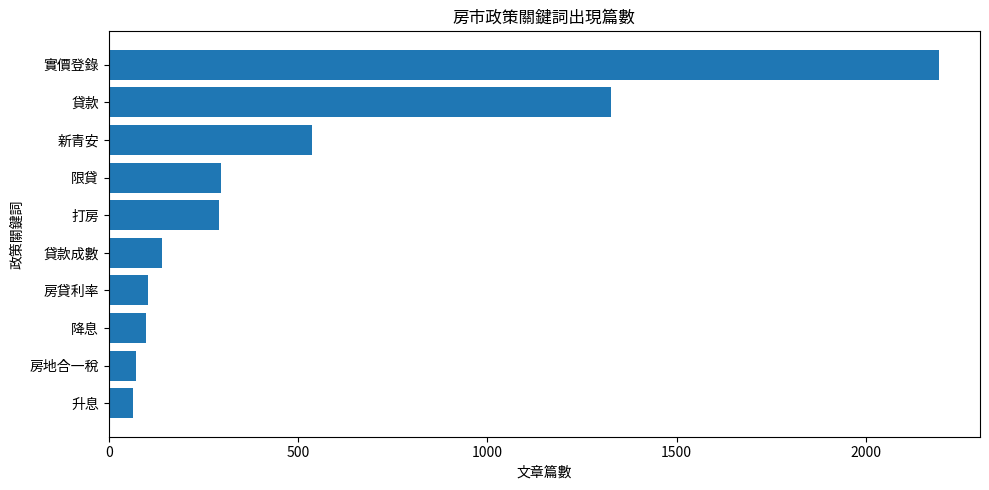

In [71]:
import matplotlib.pyplot as plt

plot_df = policy_df.head(10).iloc[::-1]

plt.figure(figsize=(10, 5))
plt.barh(plot_df['policy_word'], plot_df['article_count'])
plt.title('房市政策關鍵詞出現篇數')
plt.xlabel('文章篇數')
plt.ylabel('政策關鍵詞')
plt.tight_layout()
plt.show()

## 九、結論與綜合洞察

本研究針對 PTT 房屋版（home-sale）進行社群媒體分析，透過爬取的 9,812 篇文章與超過 42 萬則推文，回答初始設定之研究問題：

### 1. PTT 房屋版最常討論哪些房市議題？
根據 **LDA 主題模型**與**高頻詞分析**，房屋版討論高度集中在：
*   **交易實務**：包含預售屋格式、建物權狀、公設比、格局請益等買賣核心資訊。
*   **區域熱點**：新竹、桃園、台中等科技業設廠或具備人口紅利之地區為熱門討論焦點。
*   **市場趨勢**：針對房價漲跌、空頭與多頭觀點的長期拉鋸，以及人口結構（少子化）對長線房市的衝擊。

### 2. 網友對房價與買房的情緒偏正面、負面或中立？
*   **模型修正與洞察**：最初 SnowNLP 判斷有 89% 為負面，但經 **BERT (Roberta) 情緒驗證**發現，大量文章實為「中性資訊交換」或「正面的物件推薦」。
*   **情緒結論**：網友對「買房」本身多抱持理性且正面的置產態度，但對於「高房價」與「購屋負擔」表現出明顯的社會焦慮。情緒分布中「中性討論」比例最高，顯示該版作為資訊平台的功能大於情緒宣洩。

### 3. 哪些關鍵字最能代表房屋版討論焦點？
透過 **TF-IDF (含 N-gram)** 找出最具代表性的焦點詞：
*   **核心關鍵字**：`建物權狀`、`實價登錄`、`新青安`、`預售屋`、`格局`。
*   這些詞彙反映出網友最在意**交易透明度**（實價登錄）與**資金槓桿條件**（新青安、貸款）。

### 4. 房市政策是否是熱門討論主題？
*   **是，且具高度影響力**。在 TF-IDF 前 20 名與 BERT 語義聚類中，`新青安`、`央行限貸`、`利率`頻繁出現。
*   政策討論通常會引發大量「箭頭」型推文（中性補充資訊），顯示政策變動是引發版友進行技術性討論、重新試算財務負擔的主要觸發點。

### 綜合洞察與建議
本研究證實 PTT 房屋版具有高度的專業化趨勢，討論內容已從單純的情緒抒發轉向深度的法律、金融與政策攻防。未來建議可針對不同「年度」進行比較，觀察新青安政策實施前後，社群對於「購屋信心」的量化轉變。